In [1]:
# ============================================
# CELDA 1: Importar librerías necesarias
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# ============================================
# CELDA 2: Cargar datos del IDEAM (CORREGIDA)
# ============================================

import numpy as np
import pandas as pd

# Cargar datos de humedad IDEAM
df_hum_ideam = pd.read_csv('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 1/data/raw/humidity/ideam_humidity_tolima_cajamarca_2015-01-01_2025-12-31_daily.csv')
df_hum_ideam['fecha'] = pd.to_datetime(df_hum_ideam['fecha'])
df_hum_ideam = df_hum_ideam.rename(columns={'valor_diario': 'humedad'})

# --- FILTRO: eliminar outliers de humedad (< 50%) ---
# Primero contar cuántos valores son < 50 antes de modificarlos
filtered_count = (df_hum_ideam['humedad'] < 50).sum()
print(f"Se marcarán como NaN {filtered_count} registros con humedad < 50%")

# Convertir esos valores en NaN
df_hum_ideam.loc[df_hum_ideam['humedad'] < 50, 'humedad'] = np.nan

# Cargar datos de precipitación IDEAM
df_prec_ideam = pd.read_csv('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 1/data/raw/precipitation/ideam_precipitation_tolima_cajamarca_2015-01-01_2025-12-31_daily.csv')
df_prec_ideam['fecha'] = pd.to_datetime(df_prec_ideam['fecha'])
df_prec_ideam = df_prec_ideam.rename(columns={'valor_diario': 'precipitacion'})


# Cargar datos de temperatura IDEAM
df_temp_ideam = pd.read_csv('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 1/data/raw/temperature/ideam_temperature_tolima_cajamarca_2015-01-01_2025-12-31_daily.csv')
df_temp_ideam['fecha'] = pd.to_datetime(df_temp_ideam['fecha'])
df_temp_ideam = df_temp_ideam.rename(columns={'valor_diario': 'temperatura'})

# Unir datos del IDEAM
df_ideam = df_temp_ideam[['fecha', 'temperatura']].merge(
    df_hum_ideam[['fecha', 'humedad']], on='fecha', how='outer'
).merge(
    df_prec_ideam[['fecha', 'precipitacion']], on='fecha', how='outer'
)

# Ordenar por fecha
df_ideam = df_ideam.sort_values('fecha').reset_index(drop=True)

print("\nDatos IDEAM cargados:")
print(f"Rango de fechas: {df_ideam['fecha'].min()} a {df_ideam['fecha'].max()}")
print(f"Total de registros: {len(df_ideam)}")
print(f"Columnas: {df_ideam.columns.tolist()}")
df_ideam.head()

Se marcarán como NaN 6 registros con humedad < 50%

Datos IDEAM cargados:
Rango de fechas: 2015-01-01 00:00:00 a 2025-12-31 00:00:00
Total de registros: 2391
Columnas: ['fecha', 'temperatura', 'humedad', 'precipitacion']


,fecha,temperatura,humedad,precipitacion
0,2015-01-01,14.454167,89.083333,4.0
1,2015-01-02,13.916667,83.875000,0.0
2,2015-01-03,14.425000,77.708333,0.0
3,2015-01-04,14.750000,80.166667,0.0
4,2015-01-05,14.016667,84.541667,0.0


In [3]:
# ============================================
# CELDA 3: Cargar datos de NASA POWER
# ============================================

# Leer archivo de NASA POWER saltando las líneas de encabezado
with open('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 1/data/raw/nasa_power/nasa_power_cajamarca_20150101_20251231_daily.csv', 'r') as file:
    lines = file.readlines()

# Encontrar la línea donde comienzan los datos
header_end = 0
for i, line in enumerate(lines):
    if line.startswith('YEAR'):
        header_end = i
        break

# Cargar datos
df_nasa = pd.read_csv('/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 1/data/raw/nasa_power/nasa_power_cajamarca_20150101_20251231_daily.csv', 
                       skiprows=header_end)

# Crear columna de fecha
df_nasa['fecha'] = pd.to_datetime(df_nasa['YEAR'].astype(str) + '-' + 
                                   df_nasa['DOY'].astype(str), format='%Y-%j')

# Renombrar columnas
df_nasa = df_nasa.rename(columns={
    'T2M': 'temperatura',
    'PRECTOTCORR': 'precipitacion',
    'RH2M': 'humedad'
})

# Seleccionar columnas relevantes
df_nasa = df_nasa[['fecha', 'temperatura', 'precipitacion', 'humedad']]

print("Datos NASA POWER cargados:")
print(f"Rango de fechas: {df_nasa['fecha'].min()} a {df_nasa['fecha'].max()}")
print(f"Total de registros: {len(df_nasa)}")
print(f"Columnas: {df_nasa.columns.tolist()}")
df_nasa.head()

Datos NASA POWER cargados:
Rango de fechas: 2015-01-01 00:00:00 a 2025-12-31 00:00:00
Total de registros: 4018
Columnas: ['fecha', 'temperatura', 'precipitacion', 'humedad']


,fecha,temperatura,precipitacion,humedad
0,2015-01-01,15.15,0.05,85.43
1,2015-01-02,14.22,0.00,83.57
2,2015-01-03,14.73,0.01,82.84
3,2015-01-04,14.71,0.12,82.98
4,2015-01-05,14.51,0.29,81.94


In [4]:
# ============================================
# CELDA 4: Análisis de datos faltantes
# ============================================

def analizar_datos_faltantes(df, nombre_fuente):
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE DATOS FALTANTES - {nombre_fuente}")
    print('='*50)
    
    total_registros = len(df)
    fecha_min = df['fecha'].min()
    fecha_max = df['fecha'].max()
    dias_esperados = (fecha_max - fecha_min).days + 1
    
    print(f"Período: {fecha_min.date()} a {fecha_max.date()}")
    print(f"Días esperados: {dias_esperados}")
    print(f"Registros presentes: {total_registros}")
    print(f"Diferencia: {dias_esperados - total_registros} días")
    
    for col in ['temperatura', 'humedad', 'precipitacion']:
        if col in df.columns:
            missing = df[col].isna().sum()
            missing_pct = (missing / total_registros) * 100
            zeros = (df[col] == 0).sum() if col != 'temperatura' else 0
            zeros_pct = (zeros / total_registros) * 100
            
            print(f"\n{col.upper()}:")
            print(f"  Datos faltantes: {missing} ({missing_pct:.2f}%)")
            if col != 'temperatura':
                print(f"  Valores cero: {zeros} ({zeros_pct:.2f}%)")

# Analizar ambas fuentes
analizar_datos_faltantes(df_ideam, "IDEAM")
analizar_datos_faltantes(df_nasa, "NASA POWER")


ANÁLISIS DE DATOS FALTANTES - IDEAM
Período: 2015-01-01 a 2025-12-31
Días esperados: 4018
Registros presentes: 2391
Diferencia: 1627 días

TEMPERATURA:
  Datos faltantes: 28 (1.17%)

HUMEDAD:
  Datos faltantes: 19 (0.79%)
  Valores cero: 0 (0.00%)

PRECIPITACION:
  Datos faltantes: 9 (0.38%)
  Valores cero: 763 (31.91%)

ANÁLISIS DE DATOS FALTANTES - NASA POWER
Período: 2015-01-01 a 2025-12-31
Días esperados: 4018
Registros presentes: 4018
Diferencia: 0 días

TEMPERATURA:
  Datos faltantes: 0 (0.00%)

HUMEDAD:
  Datos faltantes: 0 (0.00%)
  Valores cero: 0 (0.00%)

PRECIPITACION:
  Datos faltantes: 0 (0.00%)
  Valores cero: 103 (2.56%)


In [5]:
# ============================================
# CELDA 5: Preprocesamiento y unificación de datos
# ============================================

# Verificar unidades
print("UNIDADES DE LAS VARIABLES:")
print("-" * 40)
print("IDEAM:")
print("  Temperatura: °C")
print("  Humedad: %")
print("  Precipitación: mm")
print("\nNASA POWER:")
print("  Temperatura: °C")
print("  Humedad: %")
print("  Precipitación: mm/day")
print("-" * 40)
print("✓ Las unidades son consistentes entre ambas fuentes")

# Identificar valores faltantes (en NASA, -999 indica missing)
for col in ['temperatura', 'precipitacion', 'humedad']:
    missing_nasa = (df_nasa[col] == -999).sum()
    if missing_nasa > 0:
        print(f"Reemplazando {-999} con NaN en NASA POWER - {col}: {missing_nasa} valores")
        df_nasa.loc[df_nasa[col] == -999, col] = np.nan

# Crear DataFrames combinados para comparación
df_comparacion_temp = pd.merge(
    df_ideam[['fecha', 'temperatura']].rename(columns={'temperatura': 'temp_ideam'}),
    df_nasa[['fecha', 'temperatura']].rename(columns={'temperatura': 'temp_nasa'}),
    on='fecha', how='inner'
)

df_comparacion_hum = pd.merge(
    df_ideam[['fecha', 'humedad']].rename(columns={'humedad': 'hum_ideam'}),
    df_nasa[['fecha', 'humedad']].rename(columns={'humedad': 'hum_nasa'}),
    on='fecha', how='inner'
)

df_comparacion_prec = pd.merge(
    df_ideam[['fecha', 'precipitacion']].rename(columns={'precipitacion': 'prec_ideam'}),
    df_nasa[['fecha', 'precipitacion']].rename(columns={'precipitacion': 'prec_nasa'}),
    on='fecha', how='inner'
)

print(f"\nRegistros comunes para comparación:")
print(f"Temperatura: {len(df_comparacion_temp)} días")
print(f"Humedad: {len(df_comparacion_hum)} días")
print(f"Precipitación: {len(df_comparacion_prec)} días")

UNIDADES DE LAS VARIABLES:
----------------------------------------
IDEAM:
  Temperatura: °C
  Humedad: %
  Precipitación: mm

NASA POWER:
  Temperatura: °C
  Humedad: %
  Precipitación: mm/day
----------------------------------------
✓ Las unidades son consistentes entre ambas fuentes

Registros comunes para comparación:
Temperatura: 2391 días
Humedad: 2391 días
Precipitación: 2391 días


In [6]:
# ============================================
# CELDA 5.5: Relleno completo de datos faltantes (versión mejorada)
# ============================================

import numpy as np
import pandas as pd
from scipy import stats

def fill_missing_by_month(df, var_name, lower_bound=None, upper_bound=None, seed=42):
    """
    Rellena los valores faltantes de una variable mensualmente usando una distribución normal
    basada en la media y desviación estándar de los datos existentes para ese mes.
    """
    np.random.seed(seed)
    df = df.copy()
    
    df['mes'] = df['fecha'].dt.month
    df['año'] = df['fecha'].dt.year
    
    for mes in range(1, 13):
        mask_mes = df['mes'] == mes
        datos_mes = df.loc[mask_mes, var_name].dropna()
        
        if len(datos_mes) == 0:
            print(f"  Advertencia: No hay datos para el mes {mes} en {var_name}, no se puede rellenar.")
            continue
        
        media = datos_mes.mean()
        std = datos_mes.std()
        if std == 0:
            std = media * 0.01 if media != 0 else 0.1
        
        nan_idx = df.loc[mask_mes & df[var_name].isna()].index
        
        if len(nan_idx) > 0:
            valores_generados = np.random.normal(loc=media, scale=std, size=len(nan_idx))
            if lower_bound is not None:
                valores_generados = np.maximum(valores_generados, lower_bound)
            if upper_bound is not None:
                valores_generados = np.minimum(valores_generados, upper_bound)
            df.loc[nan_idx, var_name] = valores_generados
            print(f"  Mes {mes}: {len(nan_idx)} valores rellenados (media={media:.2f}, std={std:.2f})")
    
    df.drop(['mes', 'año'], axis=1, inplace=True)
    return df

print("="*60)
print("PASO 1: Crear series diarias completas (sin días faltantes)")
print("="*60)

# Determinar el rango de fechas completo desde la fecha más antigua hasta la más reciente
fecha_min = min(df_ideam['fecha'].min(), df_nasa['fecha'].min())
fecha_max = max(df_ideam['fecha'].max(), df_nasa['fecha'].max())
fechas_completas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')

print(f"Rango completo: {fecha_min.date()} a {fecha_max.date()} ({len(fechas_completas)} días)")

# Reindexar ambos DataFrames para que tengan todas las fechas
df_ideam_completo = df_ideam.set_index('fecha').reindex(fechas_completas).reset_index()
df_ideam_completo.rename(columns={'index': 'fecha'}, inplace=True)

df_nasa_completo = df_nasa.set_index('fecha').reindex(fechas_completas).reset_index()
df_nasa_completo.rename(columns={'index': 'fecha'}, inplace=True)

print("\nAntes del relleno:")
print(f"IDEAM - temperatura NaNs: {df_ideam_completo['temperatura'].isna().sum()}")
print(f"IDEAM - humedad NaNs: {df_ideam_completo['humedad'].isna().sum()}")
print(f"IDEAM - precipitacion NaNs: {df_ideam_completo['precipitacion'].isna().sum()}")
print(f"NASA - temperatura NaNs: {df_nasa_completo['temperatura'].isna().sum()}")
print(f"NASA - humedad NaNs: {df_nasa_completo['humedad'].isna().sum()}")
print(f"NASA - precipitacion NaNs: {df_nasa_completo['precipitacion'].isna().sum()}")

print("\n" + "="*60)
print("PASO 2: Rellenar datos faltantes en IDEAM")
print("="*60)
df_ideam_completo = fill_missing_by_month(df_ideam_completo, 'temperatura', lower_bound=0, upper_bound=30)
df_ideam_completo = fill_missing_by_month(df_ideam_completo, 'humedad', lower_bound=0, upper_bound=100)
df_ideam_completo = fill_missing_by_month(df_ideam_completo, 'precipitacion', lower_bound=0)

print("\n" + "="*60)
print("PASO 3: Rellenar datos faltantes en NASA POWER")
print("="*60)
df_nasa_completo = fill_missing_by_month(df_nasa_completo, 'temperatura', lower_bound=0, upper_bound=30)
df_nasa_completo = fill_missing_by_month(df_nasa_completo, 'humedad', lower_bound=0, upper_bound=100)
df_nasa_completo = fill_missing_by_month(df_nasa_completo, 'precipitacion', lower_bound=0)

# Verificar que ya no hay NaNs
print("\nVERIFICACIÓN DE DATOS FALTANTES DESPUÉS DEL RELLENO:")
print("-"*50)
print(f"IDEAM - temperatura: {df_ideam_completo['temperatura'].isna().sum()} NaNs")
print(f"IDEAM - humedad: {df_ideam_completo['humedad'].isna().sum()} NaNs")
print(f"IDEAM - precipitacion: {df_ideam_completo['precipitacion'].isna().sum()} NaNs")
print(f"NASA - temperatura: {df_nasa_completo['temperatura'].isna().sum()} NaNs")
print(f"NASA - humedad: {df_nasa_completo['humedad'].isna().sum()} NaNs")
print(f"NASA - precipitacion: {df_nasa_completo['precipitacion'].isna().sum()} NaNs")

# Sobrescribir los dataframes originales con los completos
df_ideam = df_ideam_completo.copy()
df_nasa = df_nasa_completo.copy()

# Recrear los dataframes de comparación con todos los días (inner join, ahora serán todos)
print("\nRECREANDO DATAFRAMES DE COMPARACIÓN CON DATOS COMPLETOS:")
df_comparacion_temp = pd.merge(
    df_ideam[['fecha', 'temperatura']].rename(columns={'temperatura': 'temp_ideam'}),
    df_nasa[['fecha', 'temperatura']].rename(columns={'temperatura': 'temp_nasa'}),
    on='fecha', how='inner'
)

df_comparacion_hum = pd.merge(
    df_ideam[['fecha', 'humedad']].rename(columns={'humedad': 'hum_ideam'}),
    df_nasa[['fecha', 'humedad']].rename(columns={'humedad': 'hum_nasa'}),
    on='fecha', how='inner'
)

df_comparacion_prec = pd.merge(
    df_ideam[['fecha', 'precipitacion']].rename(columns={'precipitacion': 'prec_ideam'}),
    df_nasa[['fecha', 'precipitacion']].rename(columns={'precipitacion': 'prec_nasa'}),
    on='fecha', how='inner'
)

print(f"Temperatura: {len(df_comparacion_temp)} registros (deben ser {len(fechas_completas)})")
print(f"Humedad: {len(df_comparacion_hum)} registros")
print(f"Precipitación: {len(df_comparacion_prec)} registros")

print("\n¡Listo! Ahora todas las series tienen datos diarios continuos.")

PASO 1: Crear series diarias completas (sin días faltantes)
Rango completo: 2015-01-01 a 2025-12-31 (4018 días)

Antes del relleno:
IDEAM - temperatura NaNs: 1655
IDEAM - humedad NaNs: 1646
IDEAM - precipitacion NaNs: 1636
NASA - temperatura NaNs: 0
NASA - humedad NaNs: 0
NASA - precipitacion NaNs: 0

PASO 2: Rellenar datos faltantes en IDEAM
  Mes 1: 91 valores rellenados (media=14.85, std=1.01)
  Mes 2: 99 valores rellenados (media=15.15, std=1.04)
  Mes 3: 142 valores rellenados (media=15.18, std=1.01)
  Mes 4: 143 valores rellenados (media=15.44, std=1.00)
  Mes 5: 172 valores rellenados (media=15.31, std=0.85)
  Mes 6: 153 valores rellenados (media=14.99, std=0.87)
  Mes 7: 160 valores rellenados (media=14.97, std=0.95)
  Mes 8: 177 valores rellenados (media=14.99, std=0.92)
  Mes 9: 163 valores rellenados (media=15.31, std=1.04)
  Mes 10: 151 valores rellenados (media=14.96, std=0.80)
  Mes 11: 97 valores rellenados (media=15.07, std=0.84)
  Mes 12: 107 valores rellenados (media=

In [7]:
# Ejemplo para temperatura IDEAM
print("Estadísticas IDEAM:")
print(df_ideam['temperatura'].describe())
print("\nEstadísticas NASA POWER:")
print(df_nasa['temperatura'].describe())

Estadísticas IDEAM:
count    4018.000000
mean       15.127129
std         0.945368
min        11.712500
25%        14.495697
50%        15.165348
75%        15.766667
max        19.066956
Name: temperatura, dtype: float64

Estadísticas NASA POWER:
count    4018.000000
mean       15.369263
std         0.755049
min        12.870000
25%        14.880000
50%        15.350000
75%        15.840000
max        18.140000
Name: temperatura, dtype: float64


In [8]:
# Ejemplo para humedad IDEAM
print("Estadísticas IDEAM:")
print(df_ideam['humedad'].describe())
print("\nEstadísticas NASA POWER:")
print(df_nasa['humedad'].describe())

Estadísticas IDEAM:
count    4018.000000
mean       88.415657
std         5.178425
min        56.347826
25%        85.541667
50%        88.958333
75%        91.912472
max       100.000000
Name: humedad, dtype: float64

Estadísticas NASA POWER:
count    4018.00000
mean       86.61785
std         3.70130
min        66.61000
25%        84.20000
50%        86.83000
75%        89.27750
max        96.77000
Name: humedad, dtype: float64


In [9]:
# Ejemplo para temperatura IDEAM
print("Estadísticas IDEAM:")
print(df_ideam['precipitacion'].describe())
print("\nEstadísticas NASA POWER:")
print(df_nasa['precipitacion'].describe())

Estadísticas IDEAM:
count    4018.000000
mean        3.759646
std         5.130629
min         0.000000
25%         0.000000
50%         1.600000
75%         5.902112
max        47.100000
Name: precipitacion, dtype: float64

Estadísticas NASA POWER:
count    4018.000000
mean        4.656887
std         6.056773
min         0.000000
25%         0.610000
50%         2.350000
75%         6.297500
max        57.050000
Name: precipitacion, dtype: float64


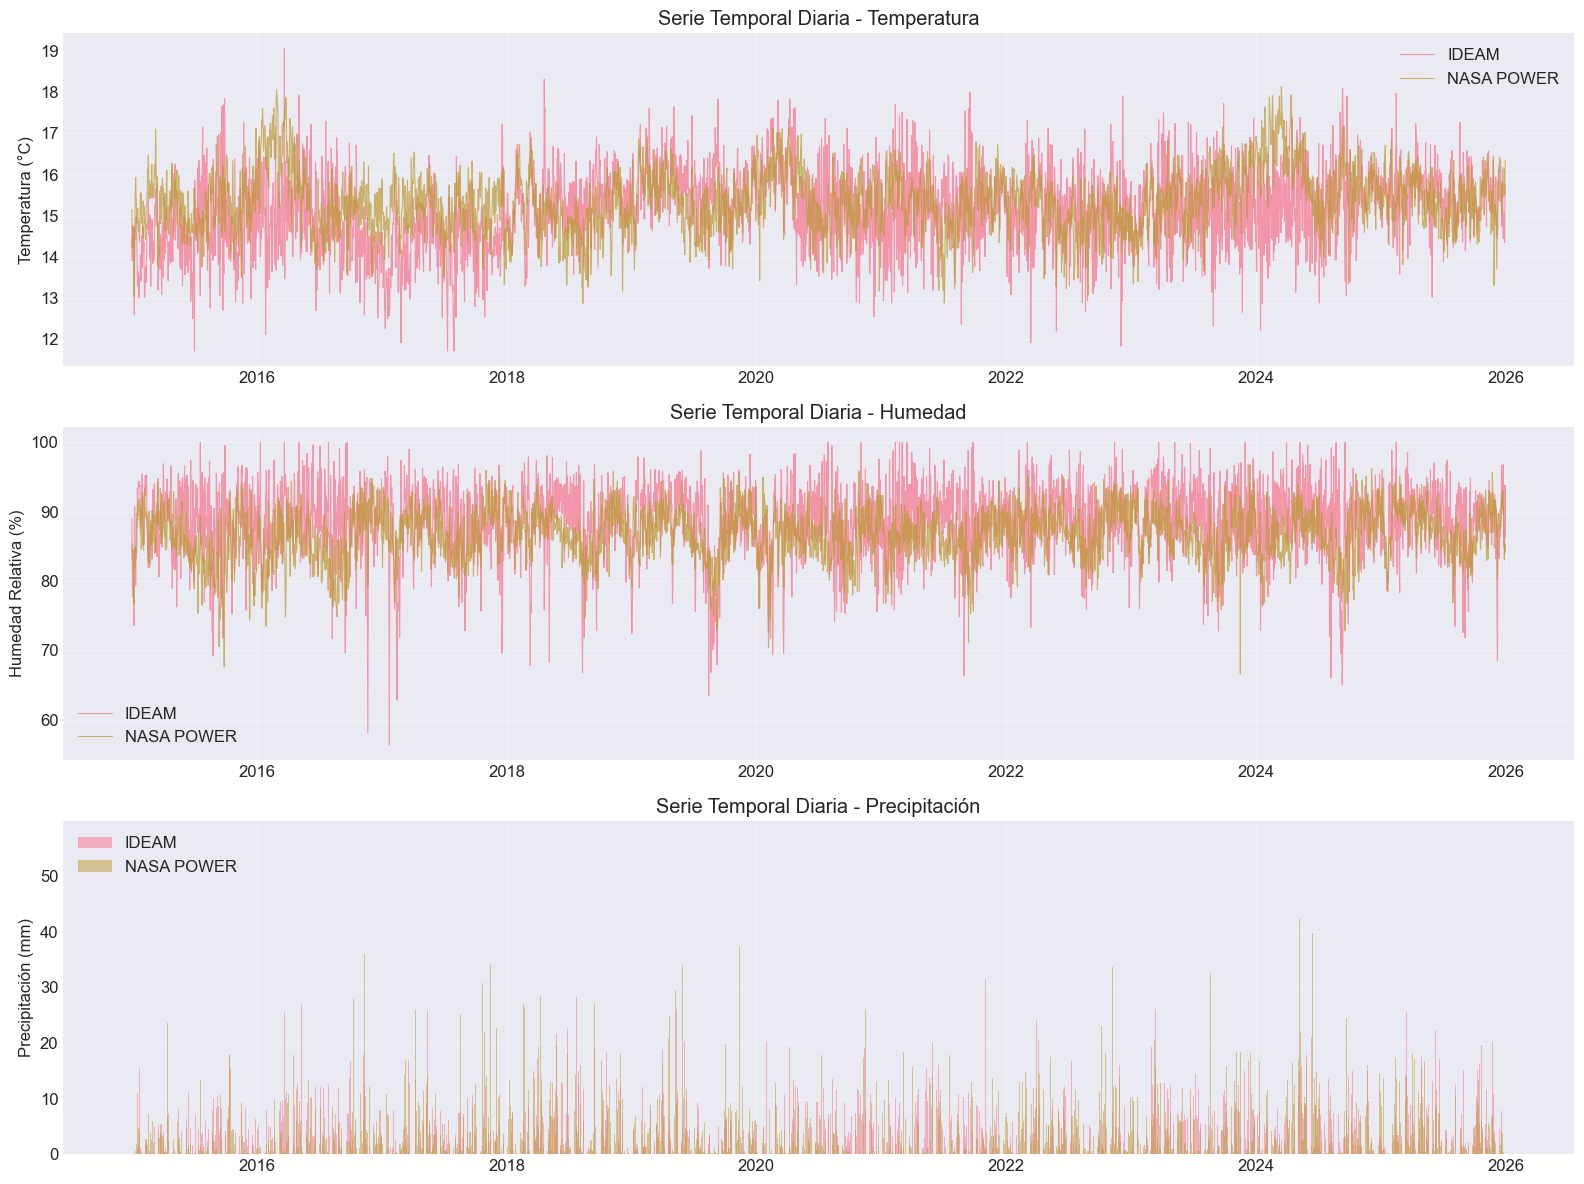

In [10]:
# ============================================
# CELDA 6: Series de tiempo diarias
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Temperatura
axes[0].plot(df_comparacion_temp['fecha'], df_comparacion_temp['temp_ideam'], 
             label='IDEAM', alpha=0.7, linewidth=0.8)
axes[0].plot(df_comparacion_temp['fecha'], df_comparacion_temp['temp_nasa'], 
             label='NASA POWER', alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Serie Temporal Diaria - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Humedad
axes[1].plot(df_comparacion_hum['fecha'], df_comparacion_hum['hum_ideam'], 
             label='IDEAM', alpha=0.7, linewidth=0.8)
axes[1].plot(df_comparacion_hum['fecha'], df_comparacion_hum['hum_nasa'], 
             label='NASA POWER', alpha=0.7, linewidth=0.8)
axes[1].set_ylabel('Humedad Relativa (%)')
axes[1].set_title('Serie Temporal Diaria - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precipitación
axes[2].bar(df_comparacion_prec['fecha'], df_comparacion_prec['prec_ideam'], 
            label='IDEAM', alpha=0.5, width=0.8)
axes[2].bar(df_comparacion_prec['fecha'], df_comparacion_prec['prec_nasa'], 
            label='NASA POWER', alpha=0.5, width=0.8)
axes[2].set_ylabel('Precipitación (mm)')
axes[2].set_title('Serie Temporal Diaria - Precipitación')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

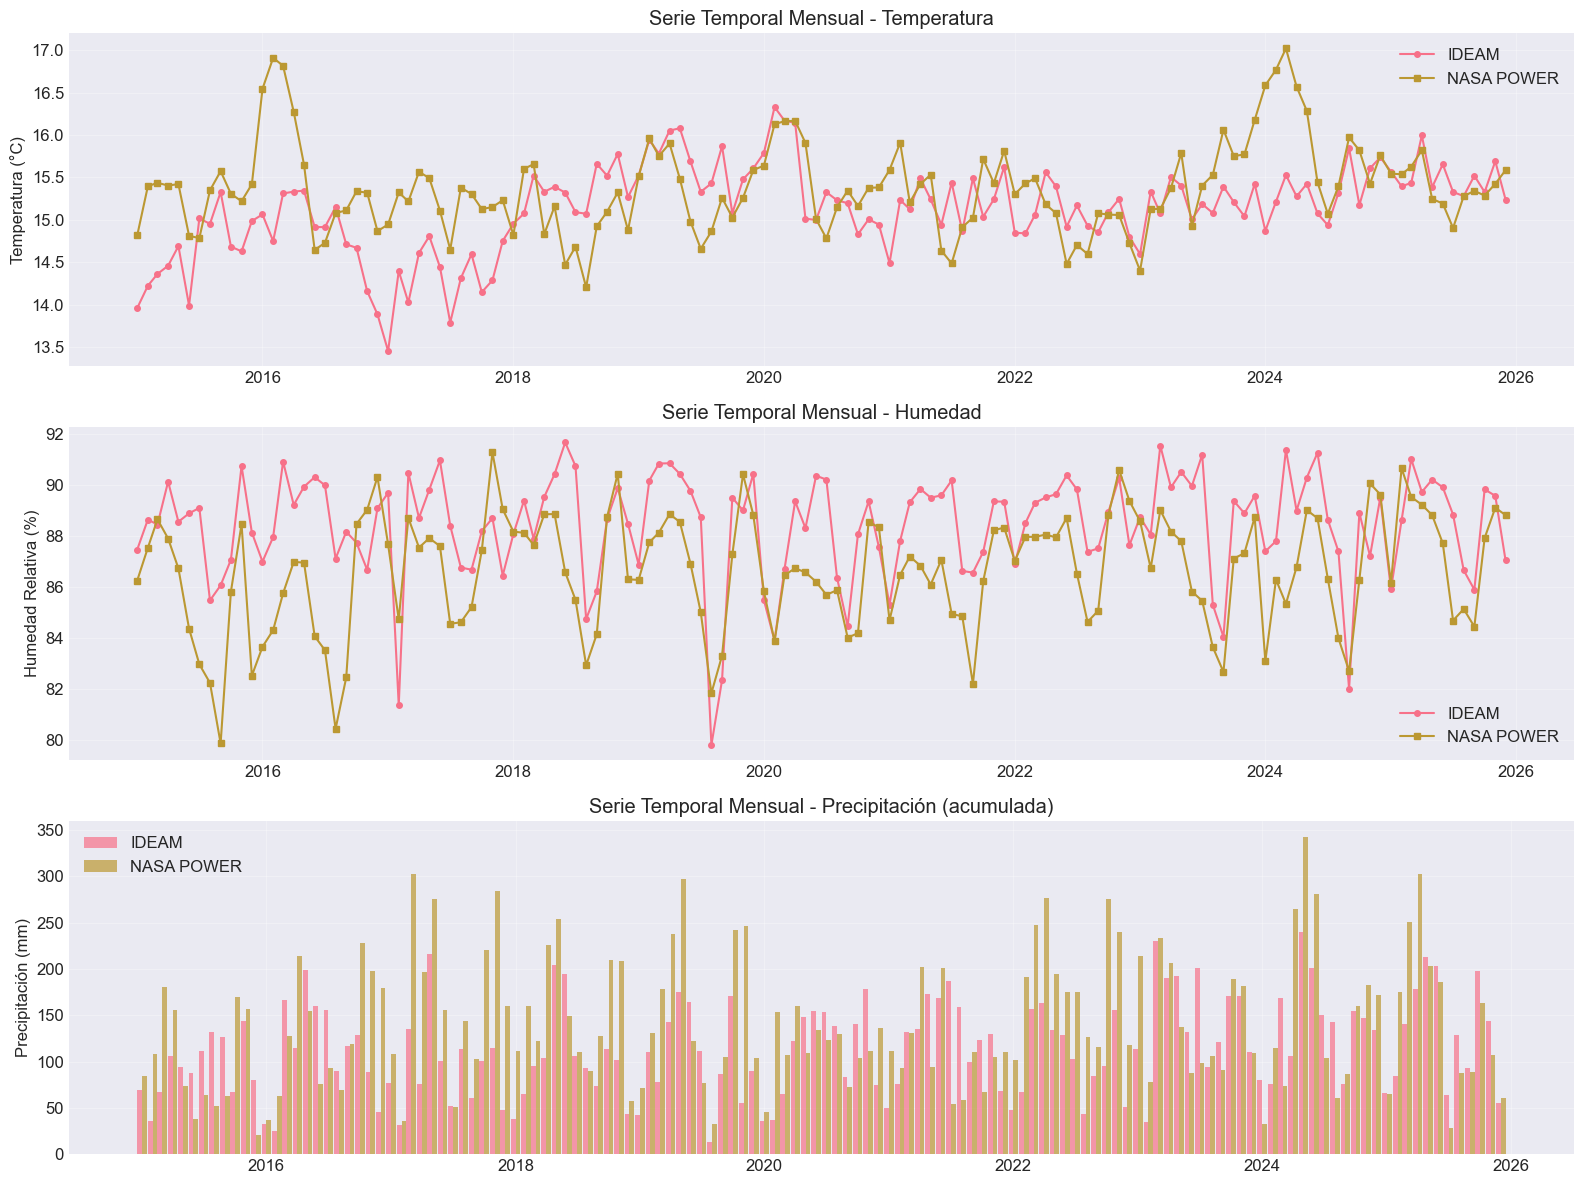

In [11]:
# ============================================
# CELDA 7: Series de tiempo mensuales
# ============================================

def agregar_mensual(df, var_ideam, var_nasa):
    df_mensual = df.copy()
    df_mensual['año'] = df_mensual['fecha'].dt.year
    df_mensual['mes'] = df_mensual['fecha'].dt.month
    df_mensual['año_mes'] = df_mensual['fecha'].dt.to_period('M')
    
    agg_dict = {var_ideam: 'mean', var_nasa: 'mean'}
    df_mensual = df_mensual.groupby('año_mes').agg(agg_dict).reset_index()
    df_mensual['fecha'] = df_mensual['año_mes'].dt.to_timestamp()
    
    return df_mensual

# Agregar datos mensuales
temp_mensual = agregar_mensual(df_comparacion_temp, 'temp_ideam', 'temp_nasa')
hum_mensual = agregar_mensual(df_comparacion_hum, 'hum_ideam', 'hum_nasa')

# Para precipitación usamos suma mensual
prec_mensual = df_comparacion_prec.copy()
prec_mensual['año_mes'] = prec_mensual['fecha'].dt.to_period('M')
prec_mensual = prec_mensual.groupby('año_mes').agg({
    'prec_ideam': 'sum',
    'prec_nasa': 'sum'
}).reset_index()
prec_mensual['fecha'] = prec_mensual['año_mes'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Temperatura mensual
axes[0].plot(temp_mensual['fecha'], temp_mensual['temp_ideam'], 
             label='IDEAM', marker='o', markersize=4)
axes[0].plot(temp_mensual['fecha'], temp_mensual['temp_nasa'], 
             label='NASA POWER', marker='s', markersize=4)
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Serie Temporal Mensual - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Humedad mensual
axes[1].plot(hum_mensual['fecha'], hum_mensual['hum_ideam'], 
             label='IDEAM', marker='o', markersize=4)
axes[1].plot(hum_mensual['fecha'], hum_mensual['hum_nasa'], 
             label='NASA POWER', marker='s', markersize=4)
axes[1].set_ylabel('Humedad Relativa (%)')
axes[1].set_title('Serie Temporal Mensual - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precipitación mensual
axes[2].bar(prec_mensual['fecha'] - pd.Timedelta(days=7), prec_mensual['prec_ideam'], 
            width=14, label='IDEAM', alpha=0.7)
axes[2].bar(prec_mensual['fecha'] + pd.Timedelta(days=7), prec_mensual['prec_nasa'], 
            width=14, label='NASA POWER', alpha=0.7)
axes[2].set_ylabel('Precipitación (mm)')
axes[2].set_title('Serie Temporal Mensual - Precipitación (acumulada)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

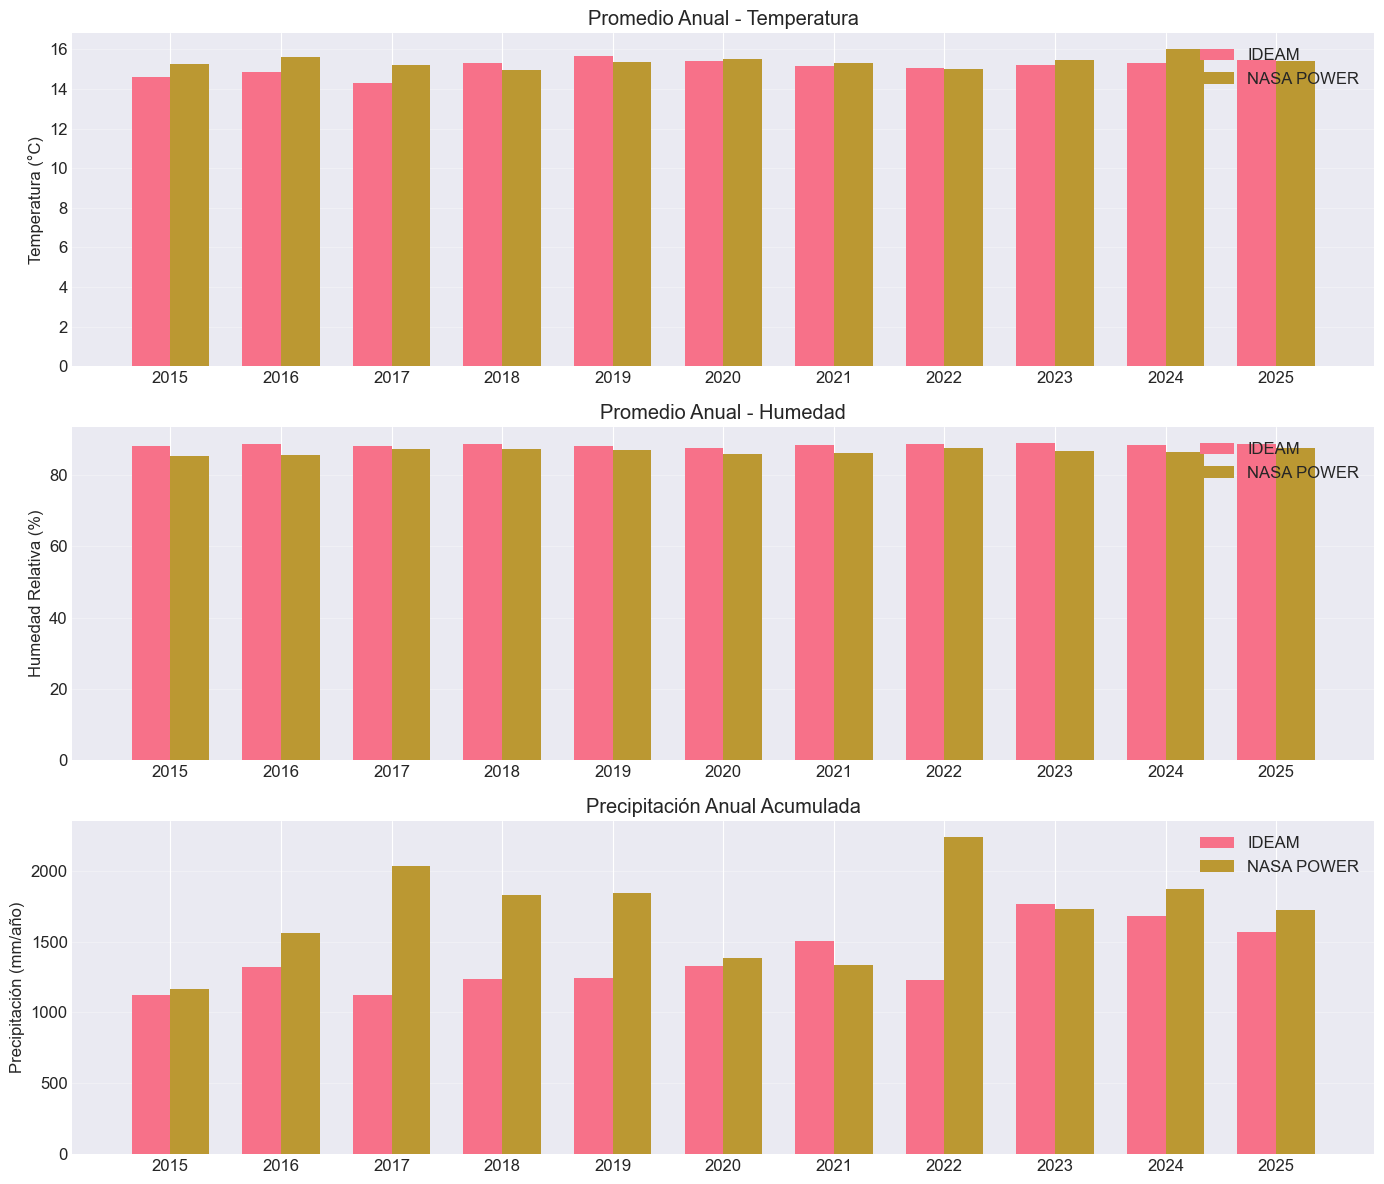


ESTADÍSTICAS ANUALES PROMEDIO:
--------------------------------------------------
Temperatura IDEAM: 15.13°C
Temperatura NASA: 15.37°C
Humedad IDEAM: 88.4%
Humedad NASA: 86.6%
Precipitación IDEAM: 1373.3 mm/año
Precipitación NASA: 1701.0 mm/año


In [12]:
# ============================================
# CELDA 8: Series de tiempo anuales
# ============================================

def agregar_anual(df, var_ideam, var_nasa, var_type='mean'):
    df_anual = df.copy()
    df_anual['año'] = df_anual['fecha'].dt.year
    
    if var_type == 'mean':
        agg_dict = {var_ideam: 'mean', var_nasa: 'mean'}
    else:  # sum para precipitación
        agg_dict = {var_ideam: 'sum', var_nasa: 'sum'}
    
    df_anual = df_anual.groupby('año').agg(agg_dict).reset_index()
    
    return df_anual

# Agregar datos anuales
temp_anual = agregar_anual(df_comparacion_temp, 'temp_ideam', 'temp_nasa', 'mean')
hum_anual = agregar_anual(df_comparacion_hum, 'hum_ideam', 'hum_nasa', 'mean')
prec_anual = agregar_anual(df_comparacion_prec, 'prec_ideam', 'prec_nasa', 'sum')

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Temperatura anual
x = np.arange(len(temp_anual))
width = 0.35
axes[0].bar(x - width/2, temp_anual['temp_ideam'], width, label='IDEAM')
axes[0].bar(x + width/2, temp_anual['temp_nasa'], width, label='NASA POWER')
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_anual['año'])
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Promedio Anual - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Humedad anual
axes[1].bar(x - width/2, hum_anual['hum_ideam'], width, label='IDEAM')
axes[1].bar(x + width/2, hum_anual['hum_nasa'], width, label='NASA POWER')
axes[1].set_xticks(x)
axes[1].set_xticklabels(hum_anual['año'])
axes[1].set_ylabel('Humedad Relativa (%)')
axes[1].set_title('Promedio Anual - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Precipitación anual
axes[2].bar(x - width/2, prec_anual['prec_ideam'], width, label='IDEAM')
axes[2].bar(x + width/2, prec_anual['prec_nasa'], width, label='NASA POWER')
axes[2].set_xticks(x)
axes[2].set_xticklabels(prec_anual['año'])
axes[2].set_ylabel('Precipitación (mm/año)')
axes[2].set_title('Precipitación Anual Acumulada')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Mostrar estadísticas anuales
print("\nESTADÍSTICAS ANUALES PROMEDIO:")
print("-" * 50)
print(f"Temperatura IDEAM: {temp_anual['temp_ideam'].mean():.2f}°C")
print(f"Temperatura NASA: {temp_anual['temp_nasa'].mean():.2f}°C")
print(f"Humedad IDEAM: {hum_anual['hum_ideam'].mean():.1f}%")
print(f"Humedad NASA: {hum_anual['hum_nasa'].mean():.1f}%")
print(f"Precipitación IDEAM: {prec_anual['prec_ideam'].mean():.1f} mm/año")
print(f"Precipitación NASA: {prec_anual['prec_nasa'].mean():.1f} mm/año")

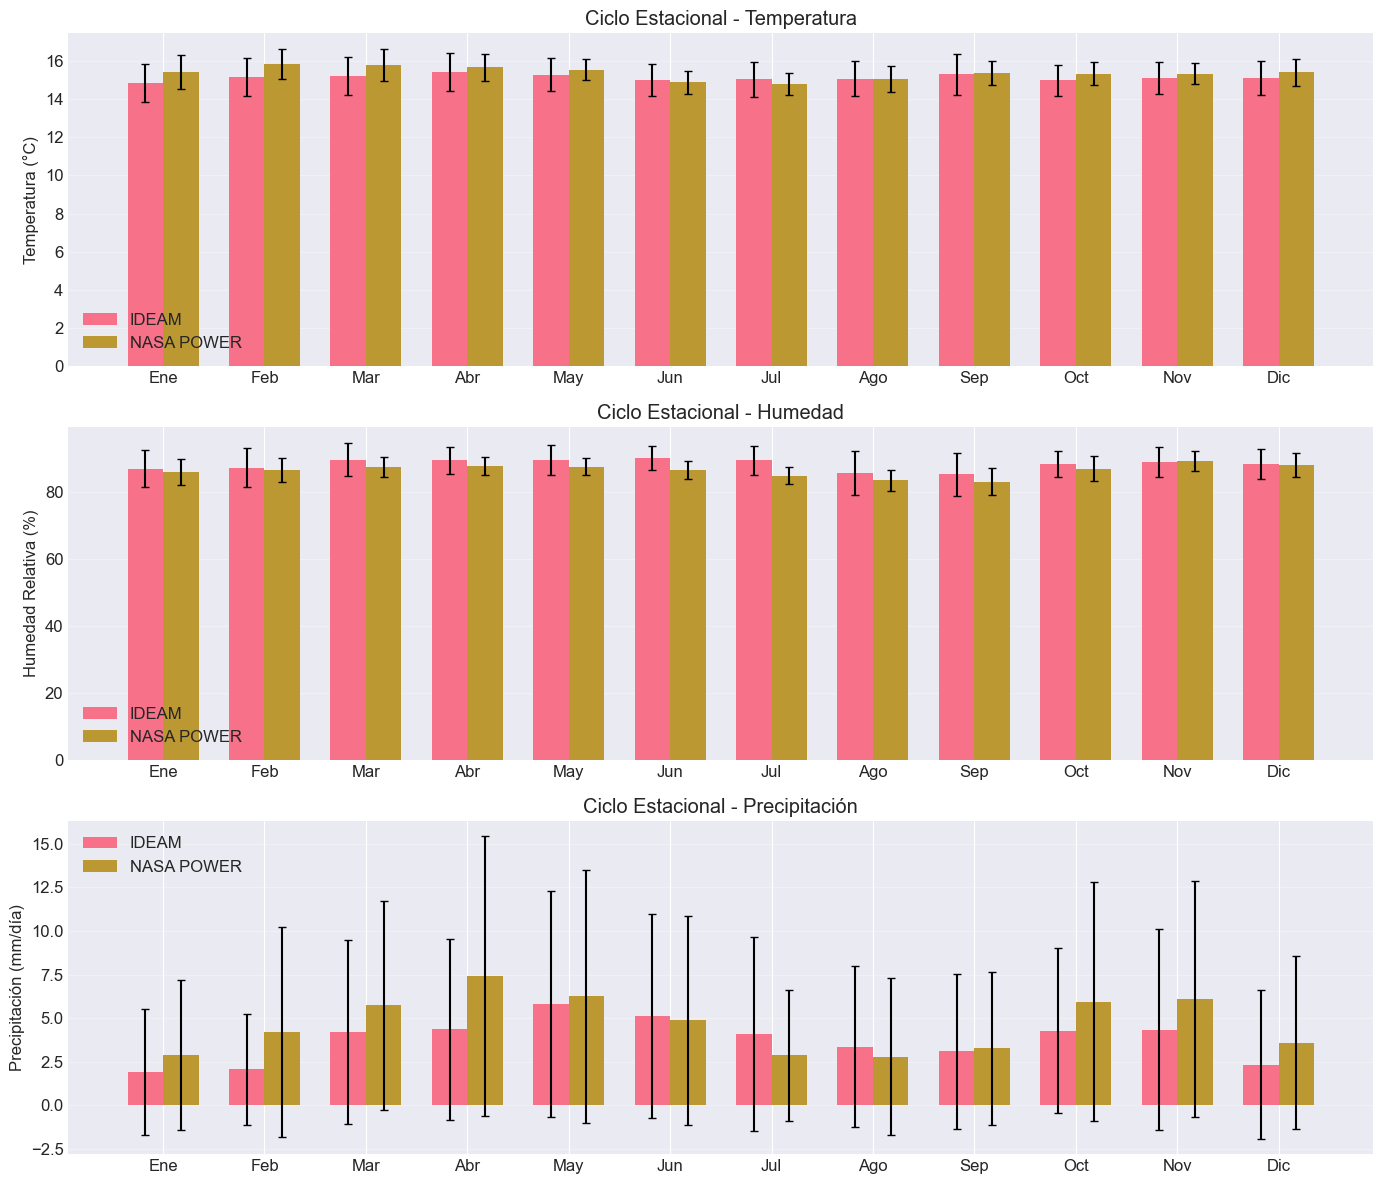


CICLO ESTACIONAL - Temperatura (°C):
------------------------------------------------------------
Mes        IDEAM           NASA            Diferencia     
------------------------------------------------------------
Ene        14.83           15.43           -0.60          
Feb        15.16           15.83           -0.67          
Mar        15.22           15.77           -0.55          
Abr        15.43           15.68           -0.25          
May        15.29           15.55           -0.26          
Jun        15.00           14.88           0.12           
Jul        15.05           14.80           0.25           
Ago        15.06           15.07           -0.01          
Sep        15.31           15.36           -0.05          
Oct        14.98           15.34           -0.36          
Nov        15.11           15.34           -0.23          
Dic        15.11           15.40           -0.29          


In [13]:
# ============================================
# CELDA 9: Ciclo estacional (climatología mensual)
# ============================================

def ciclo_estacional(df, var_ideam, var_nasa):
    df_est = df.copy()
    df_est['mes'] = df_est['fecha'].dt.month
    
    ciclo = df_est.groupby('mes').agg({
        var_ideam: ['mean', 'std'],
        var_nasa: ['mean', 'std']
    }).round(2)
    
    ciclo.columns = ['_'.join(col).strip() for col in ciclo.columns.values]
    ciclo = ciclo.reset_index()
    
    return ciclo

# Calcular ciclos estacionales
ciclo_temp = ciclo_estacional(df_comparacion_temp, 'temp_ideam', 'temp_nasa')
ciclo_hum = ciclo_estacional(df_comparacion_hum, 'hum_ideam', 'hum_nasa')
ciclo_prec = ciclo_estacional(df_comparacion_prec, 'prec_ideam', 'prec_nasa')

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Ciclo temperatura
x = np.arange(len(meses))
width = 0.35
axes[0].bar(x - width/2, ciclo_temp['temp_ideam_mean'], width, 
            yerr=ciclo_temp['temp_ideam_std'], capsize=3, label='IDEAM')
axes[0].bar(x + width/2, ciclo_temp['temp_nasa_mean'], width,
            yerr=ciclo_temp['temp_nasa_std'], capsize=3, label='NASA POWER')
axes[0].set_xticks(x)
axes[0].set_xticklabels(meses)
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Ciclo Estacional - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Ciclo humedad
axes[1].bar(x - width/2, ciclo_hum['hum_ideam_mean'], width,
            yerr=ciclo_hum['hum_ideam_std'], capsize=3, label='IDEAM')
axes[1].bar(x + width/2, ciclo_hum['hum_nasa_mean'], width,
            yerr=ciclo_hum['hum_nasa_std'], capsize=3, label='NASA POWER')
axes[1].set_xticks(x)
axes[1].set_xticklabels(meses)
axes[1].set_ylabel('Humedad Relativa (%)')
axes[1].set_title('Ciclo Estacional - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Ciclo precipitación
axes[2].bar(x - width/2, ciclo_prec['prec_ideam_mean'], width,
            yerr=ciclo_prec['prec_ideam_std'], capsize=3, label='IDEAM')
axes[2].bar(x + width/2, ciclo_prec['prec_nasa_mean'], width,
            yerr=ciclo_prec['prec_nasa_std'], capsize=3, label='NASA POWER')
axes[2].set_xticks(x)
axes[2].set_xticklabels(meses)
axes[2].set_ylabel('Precipitación (mm/día)')
axes[2].set_title('Ciclo Estacional - Precipitación')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Mostrar tabla de ciclos estacionales
print("\nCICLO ESTACIONAL - Temperatura (°C):")
print("-" * 60)
print(f"{'Mes':<10} {'IDEAM':<15} {'NASA':<15} {'Diferencia':<15}")
print("-" * 60)
for i, mes in enumerate(meses):
    diff = ciclo_temp['temp_ideam_mean'].iloc[i] - ciclo_temp['temp_nasa_mean'].iloc[i]
    print(f"{mes:<10} {ciclo_temp['temp_ideam_mean'].iloc[i]:<15.2f} {ciclo_temp['temp_nasa_mean'].iloc[i]:<15.2f} {diff:<15.2f}")

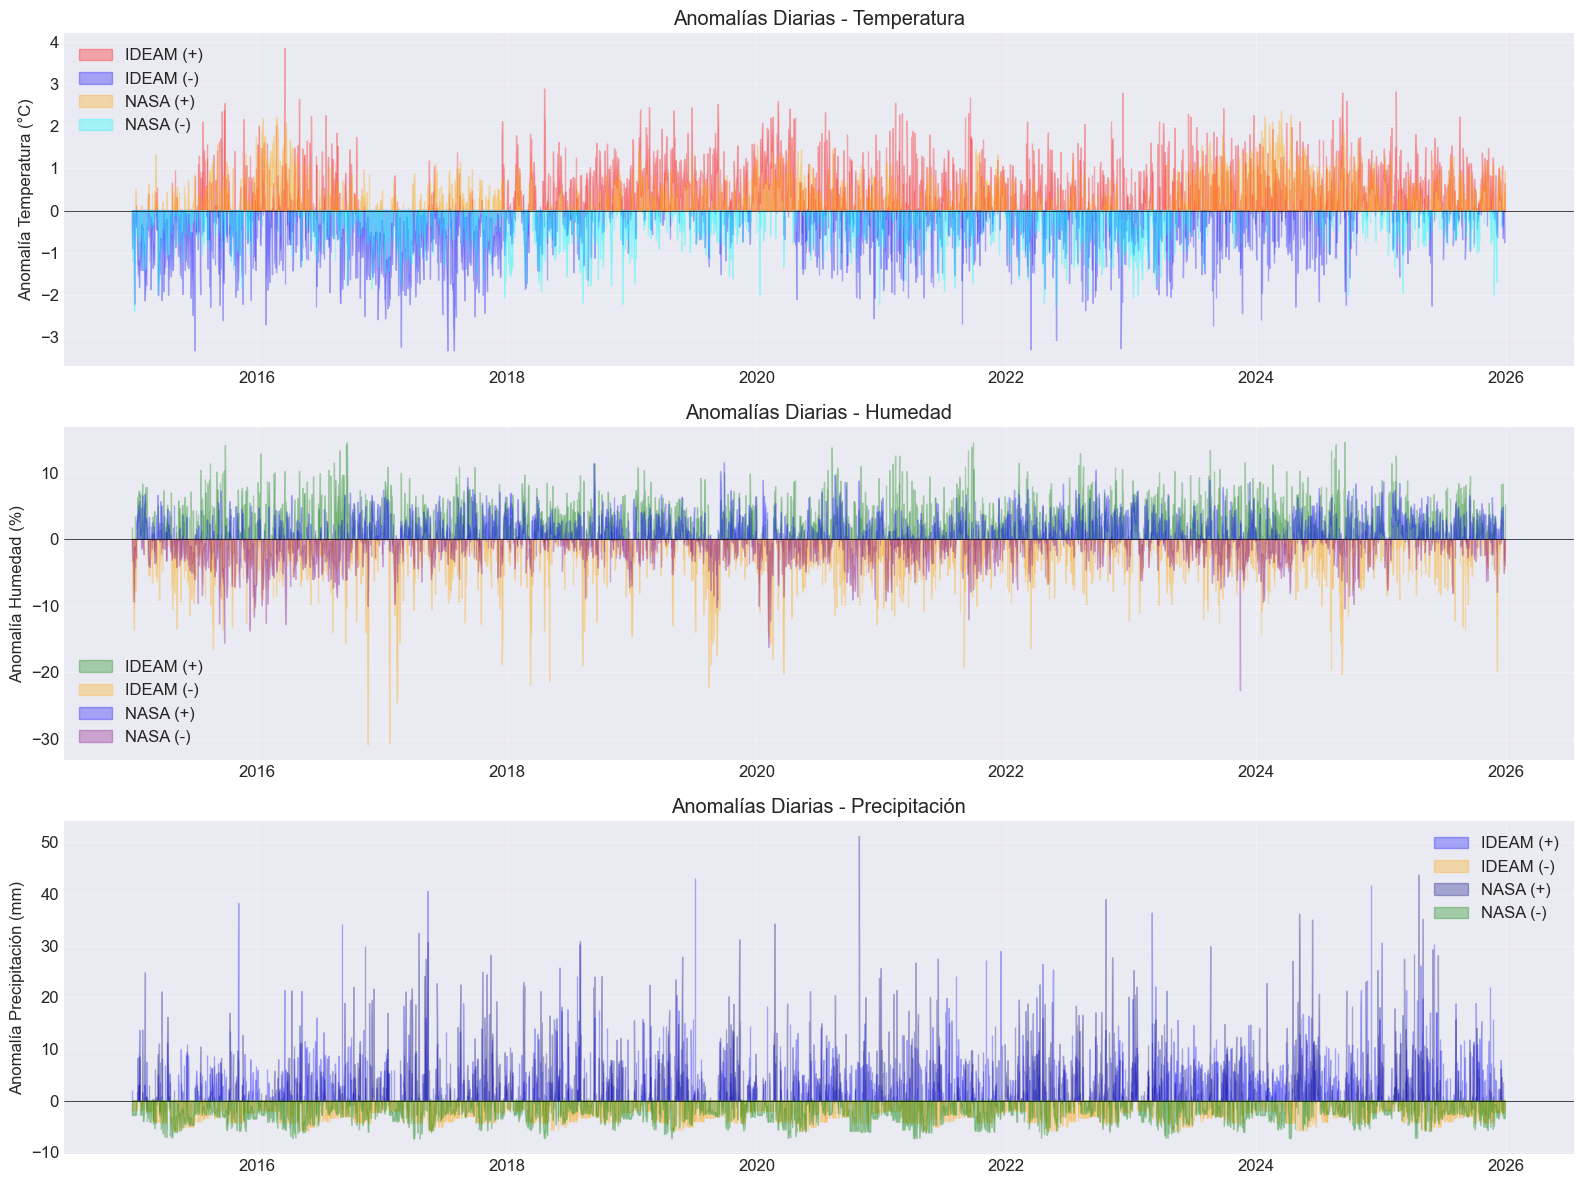


ESTADÍSTICAS DE ANOMALÍAS:
--------------------------------------------------
Temperatura - IDEAM: std=0.93°C, max=3.85°C
Temperatura - NASA: std=0.69°C, max=2.37°C
Humedad - IDEAM: std=4.9%, max=14.6%
Humedad - NASA: std=3.3%, max=11.5%


In [14]:
# ============================================
# CELDA 10: Anomalías climáticas
# ============================================

def calcular_anomalias(df, var_ideam, var_nasa):
    df_anom = df.copy()
    df_anom['mes'] = df_anom['fecha'].dt.month
    
    # Calcular climatología mensual
    clim_ideam = df_anom.groupby('mes')[var_ideam].transform('mean')
    clim_nasa = df_anom.groupby('mes')[var_nasa].transform('mean')
    
    # Calcular anomalías
    df_anom['anom_ideam'] = df_anom[var_ideam] - clim_ideam
    df_anom['anom_nasa'] = df_anom[var_nasa] - clim_nasa
    
    return df_anom

# Calcular anomalías
temp_anom = calcular_anomalias(df_comparacion_temp, 'temp_ideam', 'temp_nasa')
hum_anom = calcular_anomalias(df_comparacion_hum, 'hum_ideam', 'hum_nasa')
prec_anom = calcular_anomalias(df_comparacion_prec, 'prec_ideam', 'prec_nasa')

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Anomalías temperatura
axes[0].fill_between(temp_anom['fecha'], temp_anom['anom_ideam'], 0,
                      where=temp_anom['anom_ideam'] >= 0, color='red', alpha=0.3, label='IDEAM (+)')
axes[0].fill_between(temp_anom['fecha'], temp_anom['anom_ideam'], 0,
                      where=temp_anom['anom_ideam'] < 0, color='blue', alpha=0.3, label='IDEAM (-)')
axes[0].fill_between(temp_anom['fecha'], temp_anom['anom_nasa'], 0,
                      where=temp_anom['anom_nasa'] >= 0, color='orange', alpha=0.3, label='NASA (+)')
axes[0].fill_between(temp_anom['fecha'], temp_anom['anom_nasa'], 0,
                      where=temp_anom['anom_nasa'] < 0, color='cyan', alpha=0.3, label='NASA (-)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_ylabel('Anomalía Temperatura (°C)')
axes[0].set_title('Anomalías Diarias - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Anomalías humedad
axes[1].fill_between(hum_anom['fecha'], hum_anom['anom_ideam'], 0,
                      where=hum_anom['anom_ideam'] >= 0, color='green', alpha=0.3, label='IDEAM (+)')
axes[1].fill_between(hum_anom['fecha'], hum_anom['anom_ideam'], 0,
                      where=hum_anom['anom_ideam'] < 0, color='orange', alpha=0.3, label='IDEAM (-)')
axes[1].fill_between(hum_anom['fecha'], hum_anom['anom_nasa'], 0,
                      where=hum_anom['anom_nasa'] >= 0, color='blue', alpha=0.3, label='NASA (+)')
axes[1].fill_between(hum_anom['fecha'], hum_anom['anom_nasa'], 0,
                      where=hum_anom['anom_nasa'] < 0, color='purple', alpha=0.3, label='NASA (-)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Anomalía Humedad (%)')
axes[1].set_title('Anomalías Diarias - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Anomalías precipitación
axes[2].fill_between(prec_anom['fecha'], prec_anom['anom_ideam'], 0,
                      where=prec_anom['anom_ideam'] >= 0, color='blue', alpha=0.3, label='IDEAM (+)')
axes[2].fill_between(prec_anom['fecha'], prec_anom['anom_ideam'], 0,
                      where=prec_anom['anom_ideam'] < 0, color='orange', alpha=0.3, label='IDEAM (-)')
axes[2].fill_between(prec_anom['fecha'], prec_anom['anom_nasa'], 0,
                      where=prec_anom['anom_nasa'] >= 0, color='navy', alpha=0.3, label='NASA (+)')
axes[2].fill_between(prec_anom['fecha'], prec_anom['anom_nasa'], 0,
                      where=prec_anom['anom_nasa'] < 0, color='green', alpha=0.3, label='NASA (-)')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Anomalía Precipitación (mm)')
axes[2].set_title('Anomalías Diarias - Precipitación')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de anomalías
print("\nESTADÍSTICAS DE ANOMALÍAS:")
print("-" * 50)
print(f"Temperatura - IDEAM: std={temp_anom['anom_ideam'].std():.2f}°C, max={temp_anom['anom_ideam'].max():.2f}°C")
print(f"Temperatura - NASA: std={temp_anom['anom_nasa'].std():.2f}°C, max={temp_anom['anom_nasa'].max():.2f}°C")
print(f"Humedad - IDEAM: std={hum_anom['anom_ideam'].std():.1f}%, max={hum_anom['anom_ideam'].max():.1f}%")
print(f"Humedad - NASA: std={hum_anom['anom_nasa'].std():.1f}%, max={hum_anom['anom_nasa'].max():.1f}%")

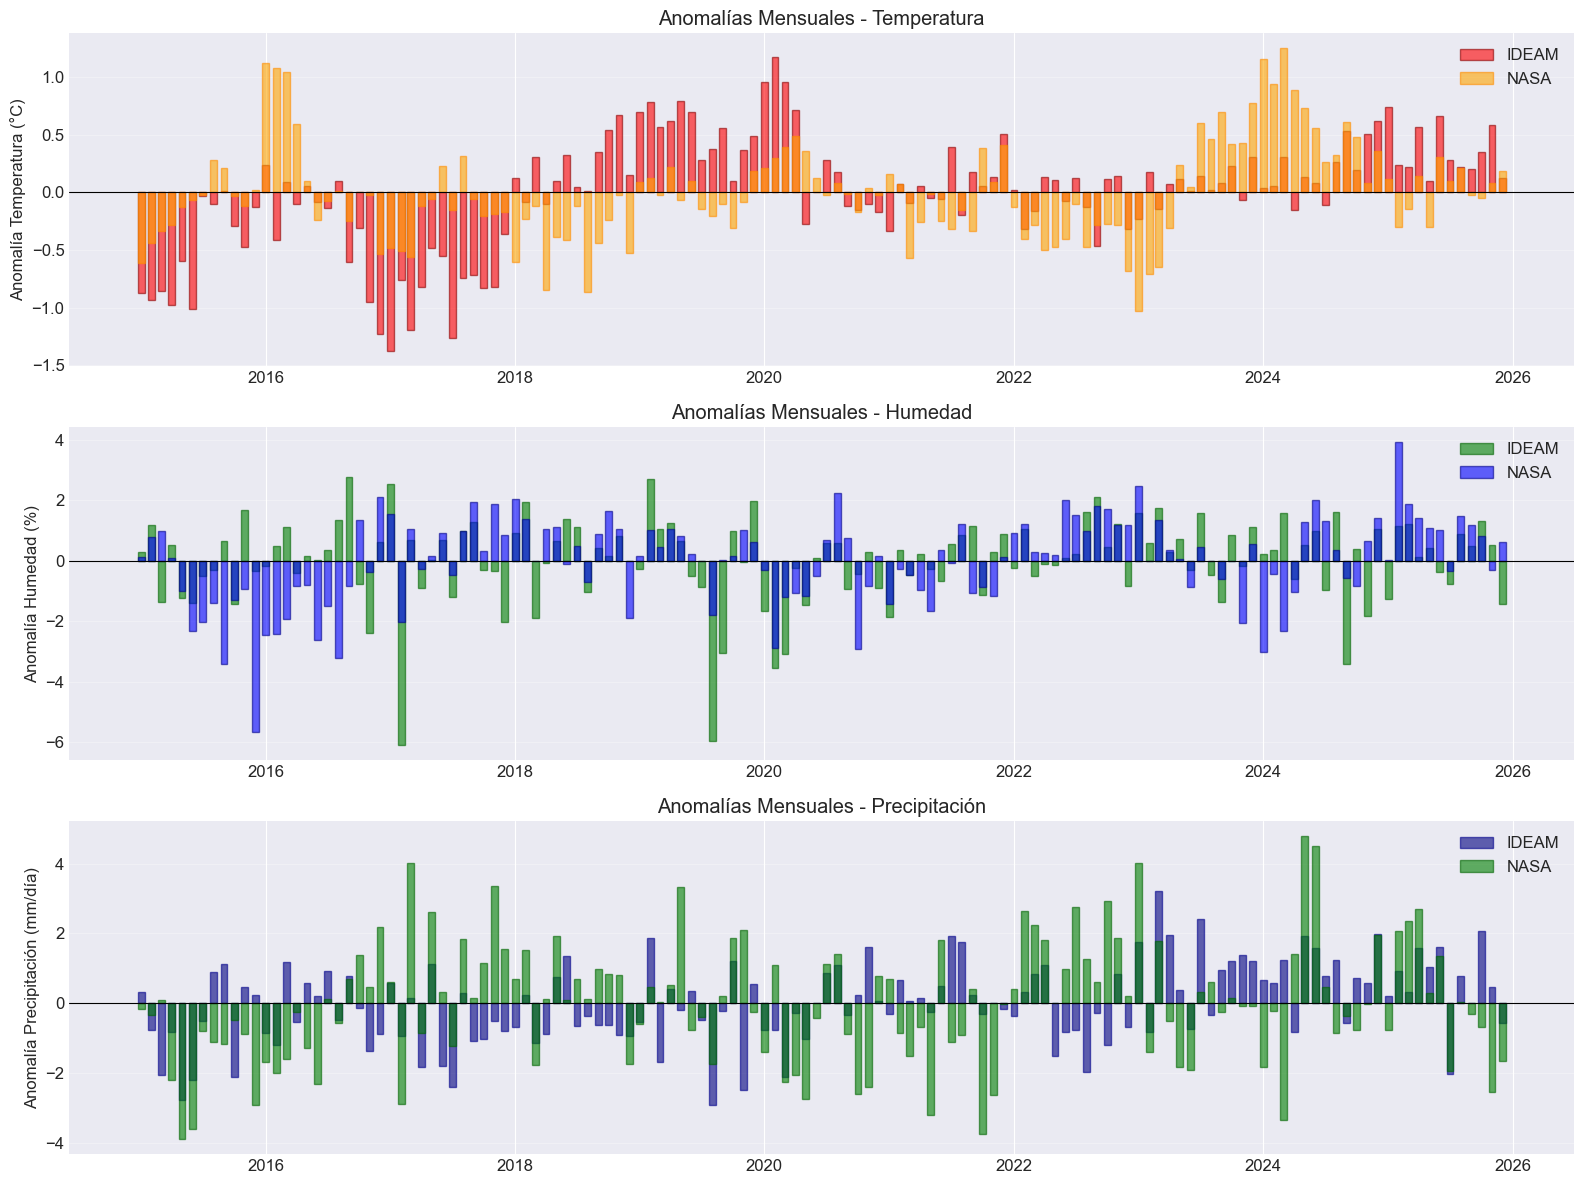

In [15]:
# ============================================
# CELDA 10b: Anomalías mensuales
# ============================================

# Calcular anomalías mensuales a partir de las anomalías diarias
def agregar_anomalias_mensuales(df_anom, var):
    df_mensual = df_anom.copy()
    df_mensual['año_mes'] = df_mensual['fecha'].dt.to_period('M')
    # Promedio mensual de las anomalías
    df_mensual = df_mensual.groupby('año_mes').agg({
        f'anom_ideam': 'mean',
        f'anom_nasa': 'mean'
    }).reset_index()
    df_mensual['fecha'] = df_mensual['año_mes'].dt.to_timestamp()
    return df_mensual

temp_anom_mensual = agregar_anomalias_mensuales(temp_anom, 'temp')
hum_anom_mensual = agregar_anomalias_mensuales(hum_anom, 'hum')
prec_anom_mensual = agregar_anomalias_mensuales(prec_anom, 'prec')

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Temperatura mensual
axes[0].bar(temp_anom_mensual['fecha'], temp_anom_mensual['anom_ideam'],
            width=20, color='red', alpha=0.6, label='IDEAM', edgecolor='darkred')
axes[0].bar(temp_anom_mensual['fecha'], temp_anom_mensual['anom_nasa'],
            width=20, bottom=0, color='orange', alpha=0.6, label='NASA', edgecolor='darkorange')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_ylabel('Anomalía Temperatura (°C)')
axes[0].set_title('Anomalías Mensuales - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Humedad mensual
axes[1].bar(hum_anom_mensual['fecha'], hum_anom_mensual['anom_ideam'],
            width=20, color='green', alpha=0.6, label='IDEAM', edgecolor='darkgreen')
axes[1].bar(hum_anom_mensual['fecha'], hum_anom_mensual['anom_nasa'],
            width=20, bottom=0, color='blue', alpha=0.6, label='NASA', edgecolor='darkblue')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Anomalía Humedad (%)')
axes[1].set_title('Anomalías Mensuales - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Precipitación mensual
axes[2].bar(prec_anom_mensual['fecha'], prec_anom_mensual['anom_ideam'],
            width=20, color='navy', alpha=0.6, label='IDEAM', edgecolor='darkblue')
axes[2].bar(prec_anom_mensual['fecha'], prec_anom_mensual['anom_nasa'],
            width=20, bottom=0, color='green', alpha=0.6, label='NASA', edgecolor='darkgreen')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_ylabel('Anomalía Precipitación (mm/día)')
axes[2].set_title('Anomalías Mensuales - Precipitación')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

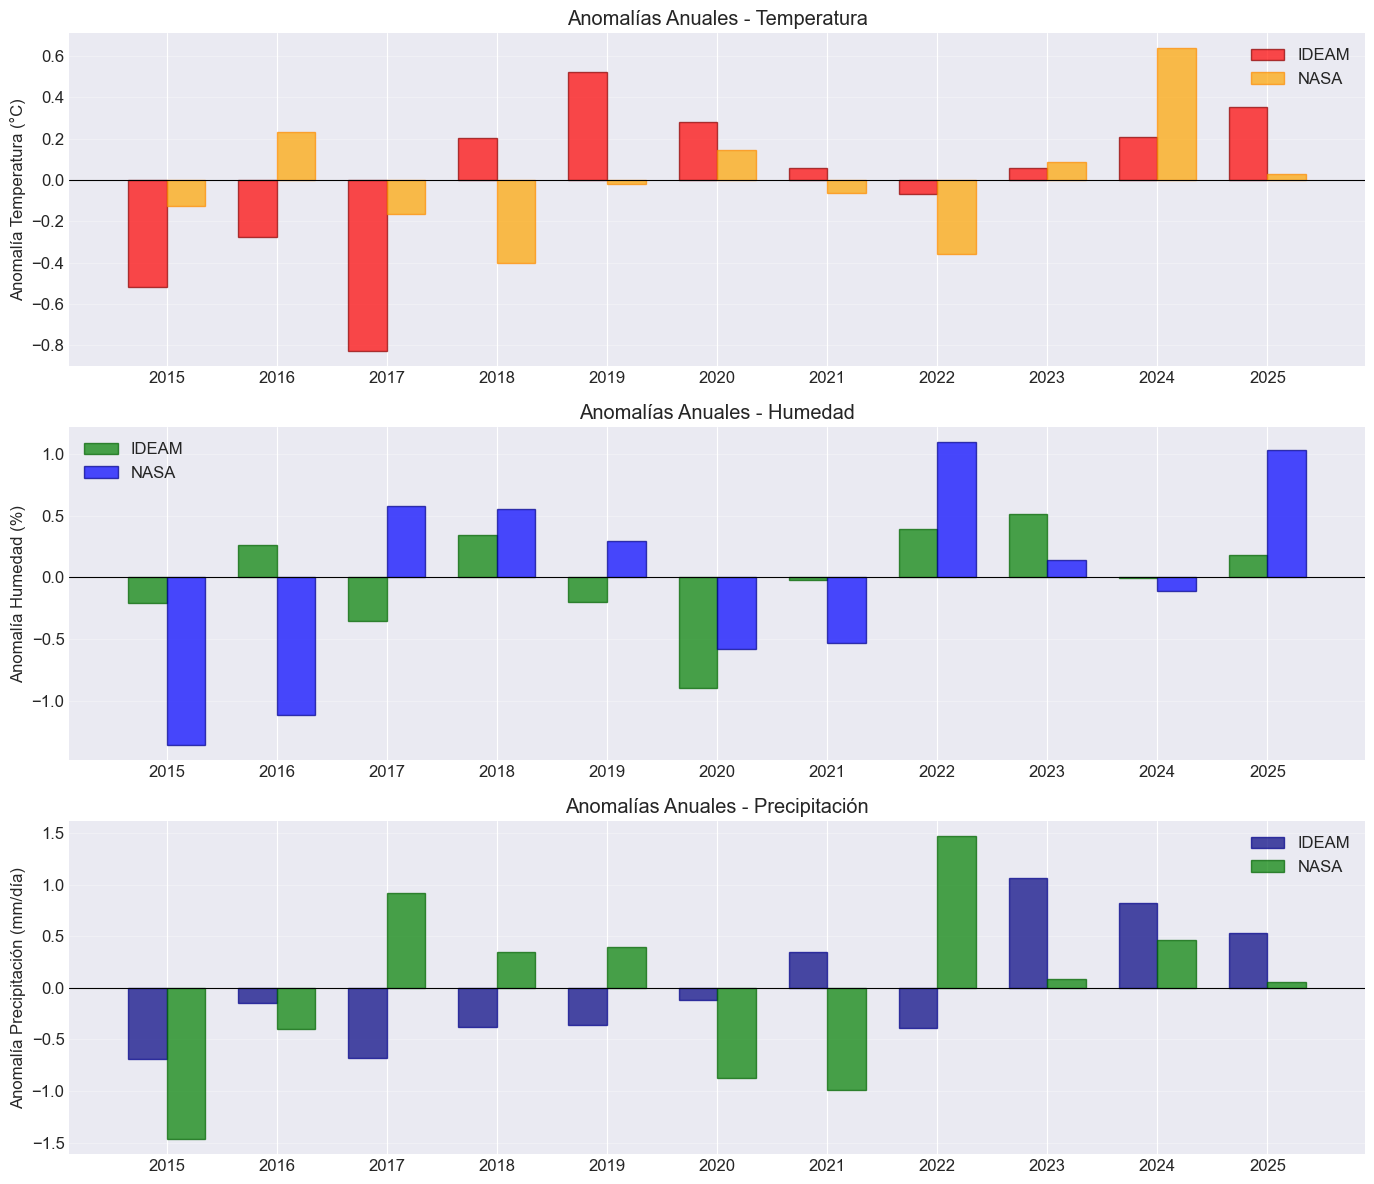

In [16]:
# ============================================
# CELDA 10c: Anomalías anuales
# ============================================

def agregar_anomalias_anuales(df_anom, var):
    df_anual = df_anom.copy()
    df_anual['año'] = df_anual['fecha'].dt.year
    df_anual = df_anual.groupby('año').agg({
        f'anom_ideam': 'mean',
        f'anom_nasa': 'mean'
    }).reset_index()
    return df_anual

temp_anom_anual = agregar_anomalias_anuales(temp_anom, 'temp')
hum_anom_anual = agregar_anomalias_anuales(hum_anom, 'hum')
prec_anom_anual = agregar_anomalias_anuales(prec_anom, 'prec')

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

x = np.arange(len(temp_anom_anual))
width = 0.35

# Temperatura anual
axes[0].bar(x - width/2, temp_anom_anual['anom_ideam'], width,
            color='red', alpha=0.7, label='IDEAM', edgecolor='darkred')
axes[0].bar(x + width/2, temp_anom_anual['anom_nasa'], width,
            color='orange', alpha=0.7, label='NASA', edgecolor='darkorange')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_anom_anual['año'])
axes[0].set_ylabel('Anomalía Temperatura (°C)')
axes[0].set_title('Anomalías Anuales - Temperatura')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Humedad anual
axes[1].bar(x - width/2, hum_anom_anual['anom_ideam'], width,
            color='green', alpha=0.7, label='IDEAM', edgecolor='darkgreen')
axes[1].bar(x + width/2, hum_anom_anual['anom_nasa'], width,
            color='blue', alpha=0.7, label='NASA', edgecolor='darkblue')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(hum_anom_anual['año'])
axes[1].set_ylabel('Anomalía Humedad (%)')
axes[1].set_title('Anomalías Anuales - Humedad')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Precipitación anual
axes[2].bar(x - width/2, prec_anom_anual['anom_ideam'], width,
            color='navy', alpha=0.7, label='IDEAM', edgecolor='darkblue')
axes[2].bar(x + width/2, prec_anom_anual['anom_nasa'], width,
            color='green', alpha=0.7, label='NASA', edgecolor='darkgreen')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(prec_anom_anual['año'])
axes[2].set_ylabel('Anomalía Precipitación (mm/día)')
axes[2].set_title('Anomalías Anuales - Precipitación')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

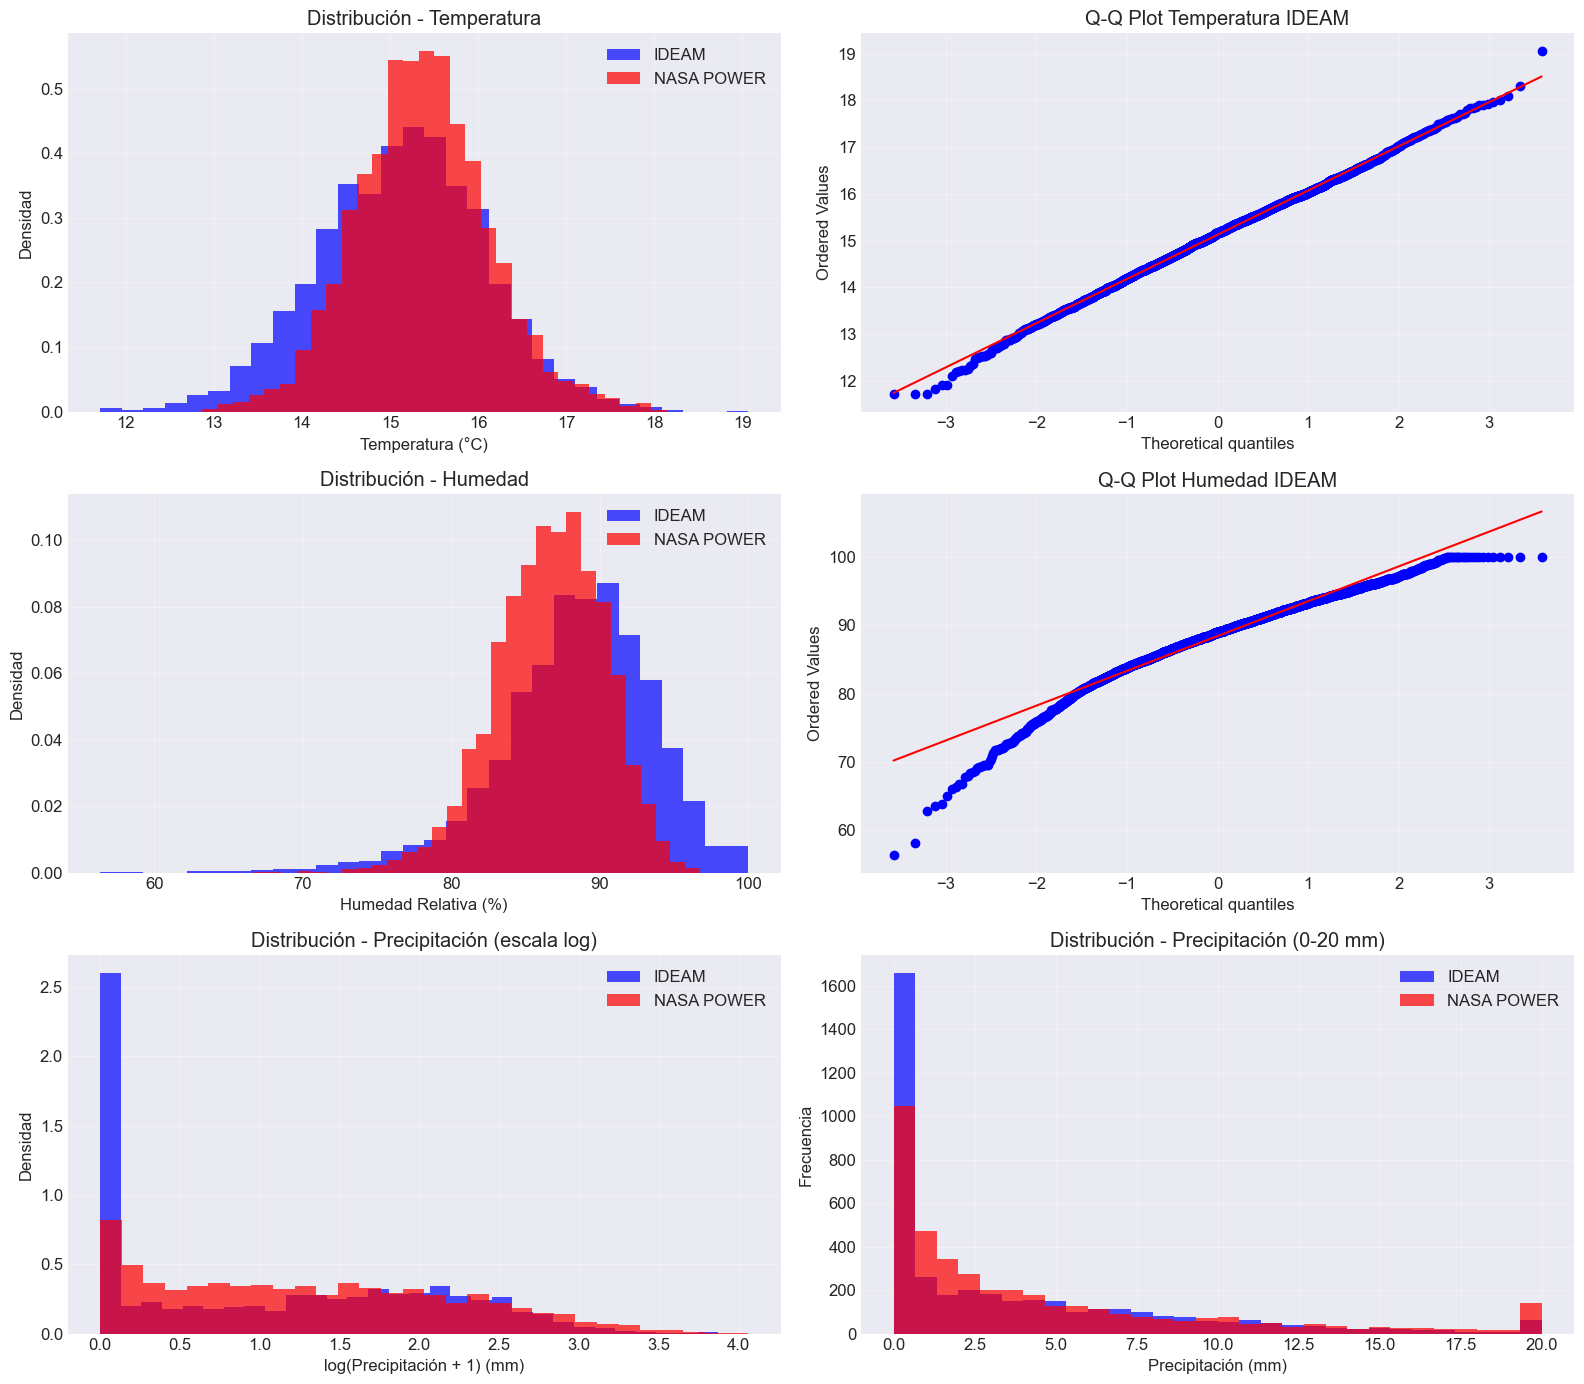


PRUEBAS DE NORMALIDAD (Shapiro-Wilk):
--------------------------------------------------
Temperatura IDEAM: p-valor = 0.0085 (No normal)
Temperatura NASA: p-valor = 0.0000 (No normal)
Humedad IDEAM: p-valor = 0.0000 (No normal)
Humedad NASA: p-valor = 0.0000 (No normal)


In [17]:
# ============================================
# CELDA 11: Histogramas y distribuciones
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Temperatura
axes[0,0].hist(df_comparacion_temp['temp_ideam'].dropna(), bins=30, alpha=0.7, 
               density=True, label='IDEAM', color='blue')
axes[0,0].hist(df_comparacion_temp['temp_nasa'].dropna(), bins=30, alpha=0.7,
               density=True, label='NASA POWER', color='red')
axes[0,0].set_xlabel('Temperatura (°C)')
axes[0,0].set_ylabel('Densidad')
axes[0,0].set_title('Distribución - Temperatura')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Q-Q plot temperatura
stats.probplot(df_comparacion_temp['temp_ideam'].dropna(), dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot Temperatura IDEAM')
axes[0,1].grid(True, alpha=0.3)

# Humedad
axes[1,0].hist(df_comparacion_hum['hum_ideam'].dropna(), bins=30, alpha=0.7,
               density=True, label='IDEAM', color='blue')
axes[1,0].hist(df_comparacion_hum['hum_nasa'].dropna(), bins=30, alpha=0.7,
               density=True, label='NASA POWER', color='red')
axes[1,0].set_xlabel('Humedad Relativa (%)')
axes[1,0].set_ylabel('Densidad')
axes[1,0].set_title('Distribución - Humedad')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Q-Q plot humedad
stats.probplot(df_comparacion_hum['hum_ideam'].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot Humedad IDEAM')
axes[1,1].grid(True, alpha=0.3)

# Precipitación (log transformada para mejor visualización)
prec_ideam_log = np.log1p(df_comparacion_prec['prec_ideam'].dropna())
prec_nasa_log = np.log1p(df_comparacion_prec['prec_nasa'].dropna())

axes[2,0].hist(prec_ideam_log, bins=30, alpha=0.7, density=True,
               label='IDEAM', color='blue')
axes[2,0].hist(prec_nasa_log, bins=30, alpha=0.7, density=True,
               label='NASA POWER', color='red')
axes[2,0].set_xlabel('log(Precipitación + 1) (mm)')
axes[2,0].set_ylabel('Densidad')
axes[2,0].set_title('Distribución - Precipitación (escala log)')
axes[2,0].legend()
axes[2,0].grid(True, alpha=0.3)

# Histograma precipitación valores reales
axes[2,1].hist(df_comparacion_prec['prec_ideam'].clip(0,20), bins=30, alpha=0.7,
               label='IDEAM', color='blue')
axes[2,1].hist(df_comparacion_prec['prec_nasa'].clip(0,20), bins=30, alpha=0.7,
               label='NASA POWER', color='red')
axes[2,1].set_xlabel('Precipitación (mm)')
axes[2,1].set_ylabel('Frecuencia')
axes[2,1].set_title('Distribución - Precipitación (0-20 mm)')
axes[2,1].legend()
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pruebas de normalidad
print("\nPRUEBAS DE NORMALIDAD (Shapiro-Wilk):")
print("-" * 50)
from scipy.stats import shapiro, kstest, norm

for var, data in [('Temperatura IDEAM', df_comparacion_temp['temp_ideam'].dropna()),
                  ('Temperatura NASA', df_comparacion_temp['temp_nasa'].dropna()),
                  ('Humedad IDEAM', df_comparacion_hum['hum_ideam'].dropna()),
                  ('Humedad NASA', df_comparacion_hum['hum_nasa'].dropna())]:
    # Tomar muestra de 5000 puntos para Shapiro (límite de la prueba)
    if len(data) > 5000:
        data_sample = data.sample(n=5000, random_state=42)
    else:
        data_sample = data
    
    stat, p = shapiro(data_sample)
    print(f"{var}: p-valor = {p:.4f} {'(No normal)' if p < 0.05 else '(Normal)'}")

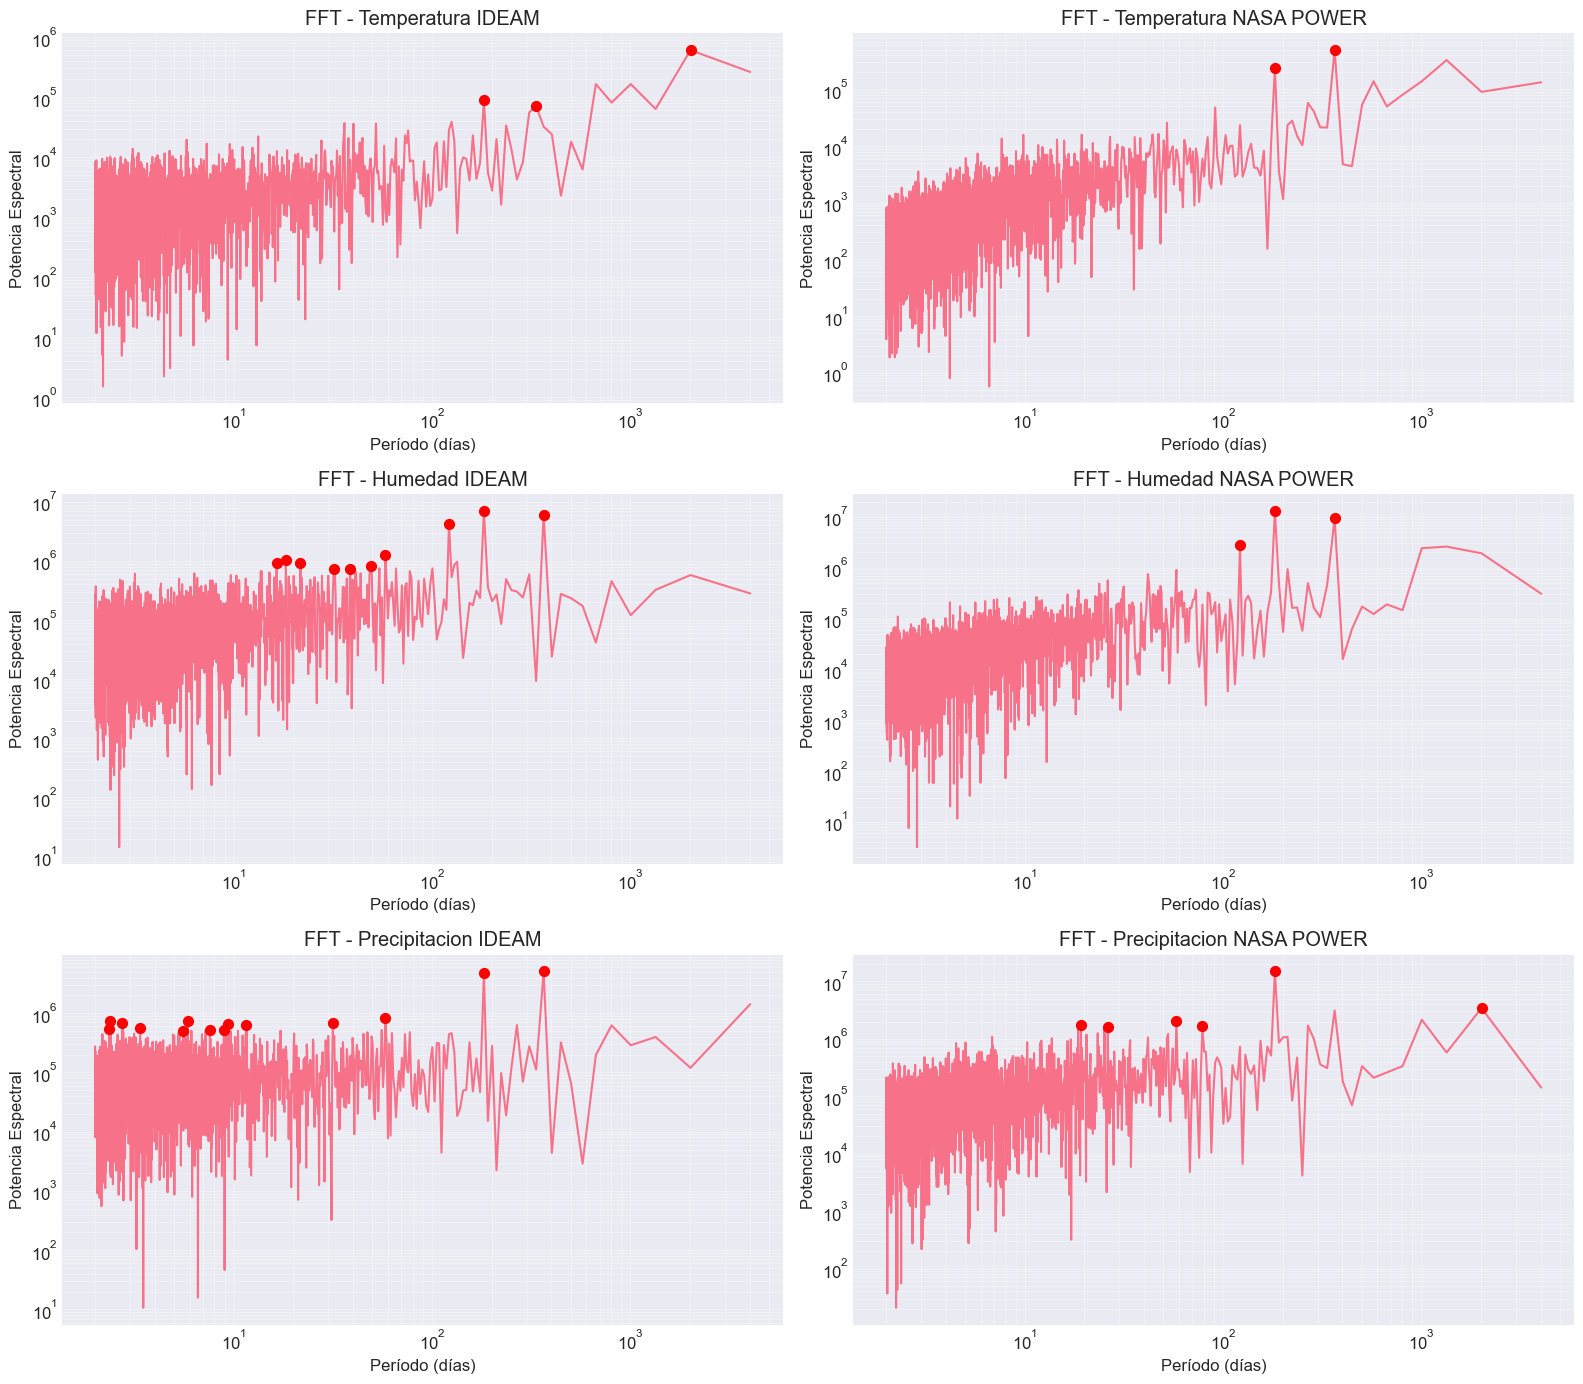


ESCALAS ESPECTRALES PRINCIPALES (períodos en días):

TEMPERATURA:
--------------------------------------------------
  IDEAM:
    Período 1: 2009.0 días (5.5 años)
    Período 2: 182.6 días (6.0 meses)
    Período 3: 334.8 días (11.0 meses)
  NASA:
    Período 1: 365.3 días (1.0 años)
    Período 2: 182.6 días (6.0 meses)

HUMEDAD:
--------------------------------------------------
  IDEAM:
    Período 1: 182.6 días (6.0 meses)
    Período 2: 365.3 días (1.0 años)
    Período 3: 121.8 días (4.0 meses)
    Período 4: 58.2 días (1.9 meses)
    Período 5: 18.3 días
  NASA:
    Período 1: 182.6 días (6.0 meses)
    Período 2: 365.3 días (1.0 años)
    Período 3: 121.8 días (4.0 meses)

PRECIPITACION:
--------------------------------------------------
  IDEAM:
    Período 1: 365.3 días (1.0 años)
    Período 2: 182.6 días (6.0 meses)
    Período 3: 58.2 días (1.9 meses)
    Período 4: 5.9 días
    Período 5: 2.4 días
  NASA:
    Período 1: 182.6 días (6.0 meses)
    Período 2: 2009.0 días 

In [18]:
# ============================================
# CELDA 12: Análisis de Fourier
# ============================================

def analisis_fourier(serie, fecha, nombre_variable, fuente):
    # Eliminar NaNs
    serie_clean = serie.dropna()
    
    if len(serie_clean) < 100:
        print(f"  {fuente} - {nombre_variable}: Datos insuficientes")
        return None
    
    # Calcular FFT
    n = len(serie_clean)
    dt = 1  # paso de tiempo en días
    freqs = fftfreq(n, dt)[:n//2]
    fft_vals = fft(serie_clean.values)
    power = np.abs(fft_vals[:n//2])**2
    
    # Filtrar frecuencias positivas y no cero
    mask = freqs > 0
    freqs_pos = freqs[mask]
    power_pos = power[mask]
    
    # Encontrar picos principales
    # Suavizar para mejor identificación
    from scipy.signal import find_peaks
    
    # Normalizar power para búsqueda de picos
    power_norm = power_pos / power_pos.max()
    peaks, properties = find_peaks(power_norm, height=0.1, distance=10)
    
    periods = 1/freqs_pos
    
    return {
        'freqs': freqs_pos,
        'power': power_pos,
        'periods': periods,
        'peaks': peaks,
        'peak_periods': periods[peaks] if len(peaks) > 0 else np.array([]),
        'peak_power': power_pos[peaks] if len(peaks) > 0 else np.array([])
    }

# Realizar análisis de Fourier para cada variable y fuente
variables = ['temperatura', 'humedad', 'precipitacion']
resultados_fft = {}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, var in enumerate(variables):
    # Datos IDEAM
    if var == 'temperatura':
        df_comp = df_comparacion_temp
        serie_ideam = df_comp['temp_ideam']
        serie_nasa = df_comp['temp_nasa']
    elif var == 'humedad':
        df_comp = df_comparacion_hum
        serie_ideam = df_comp['hum_ideam']
        serie_nasa = df_comp['hum_nasa']
    else:
        df_comp = df_comparacion_prec
        serie_ideam = df_comp['prec_ideam']
        serie_nasa = df_comp['prec_nasa']
    
    # Análisis IDEAM
    res_ideam = analisis_fourier(serie_ideam, df_comp['fecha'], var, 'IDEAM')
    if res_ideam:
        axes[i,0].loglog(res_ideam['periods'], res_ideam['power'])
        axes[i,0].scatter(res_ideam['peak_periods'], 
                         res_ideam['power'][res_ideam['peaks']] if len(res_ideam['peaks']) > 0 else [],
                         color='red', s=50, zorder=5)
        axes[i,0].set_xlabel('Período (días)')
        axes[i,0].set_ylabel('Potencia Espectral')
        axes[i,0].set_title(f'FFT - {var.capitalize()} IDEAM')
        axes[i,0].grid(True, alpha=0.3, which='both')
        
        # Guardar resultados
        resultados_fft[f'{var}_ideam'] = res_ideam
    
    # Análisis NASA
    res_nasa = analisis_fourier(serie_nasa, df_comp['fecha'], var, 'NASA')
    if res_nasa:
        axes[i,1].loglog(res_nasa['periods'], res_nasa['power'])
        axes[i,1].scatter(res_nasa['peak_periods'],
                         res_nasa['power'][res_nasa['peaks']] if len(res_nasa['peaks']) > 0 else [],
                         color='red', s=50, zorder=5)
        axes[i,1].set_xlabel('Período (días)')
        axes[i,1].set_ylabel('Potencia Espectral')
        axes[i,1].set_title(f'FFT - {var.capitalize()} NASA POWER')
        axes[i,1].grid(True, alpha=0.3, which='both')
        
        # Guardar resultados
        resultados_fft[f'{var}_nasa'] = res_nasa

plt.tight_layout()
plt.show()

# Identificar escalas espectrales principales
print("\nESCALAS ESPECTRALES PRINCIPALES (períodos en días):")
print("=" * 70)

for var in variables:
    print(f"\n{var.upper()}:")
    print("-" * 50)
    
    for fuente in ['ideam', 'nasa']:
        key = f'{var}_{fuente}'
        if key in resultados_fft:
            res = resultados_fft[key]
            if len(res['peak_periods']) > 0:
                # Ordenar por potencia
                indices = np.argsort(res['peak_power'])[::-1]
                top_periods = res['peak_periods'][indices][:5]
                
                print(f"  {fuente.upper()}:")
                for j, period in enumerate(top_periods):
                    if period > 365:
                        years = period / 365
                        print(f"    Período {j+1}: {period:.1f} días ({years:.1f} años)")
                    elif period > 30:
                        months = period / 30.44
                        print(f"    Período {j+1}: {period:.1f} días ({months:.1f} meses)")
                    else:
                        print(f"    Período {j+1}: {period:.1f} días")
            else:
                print(f"  {fuente.upper()}: No se detectaron picos significativos")

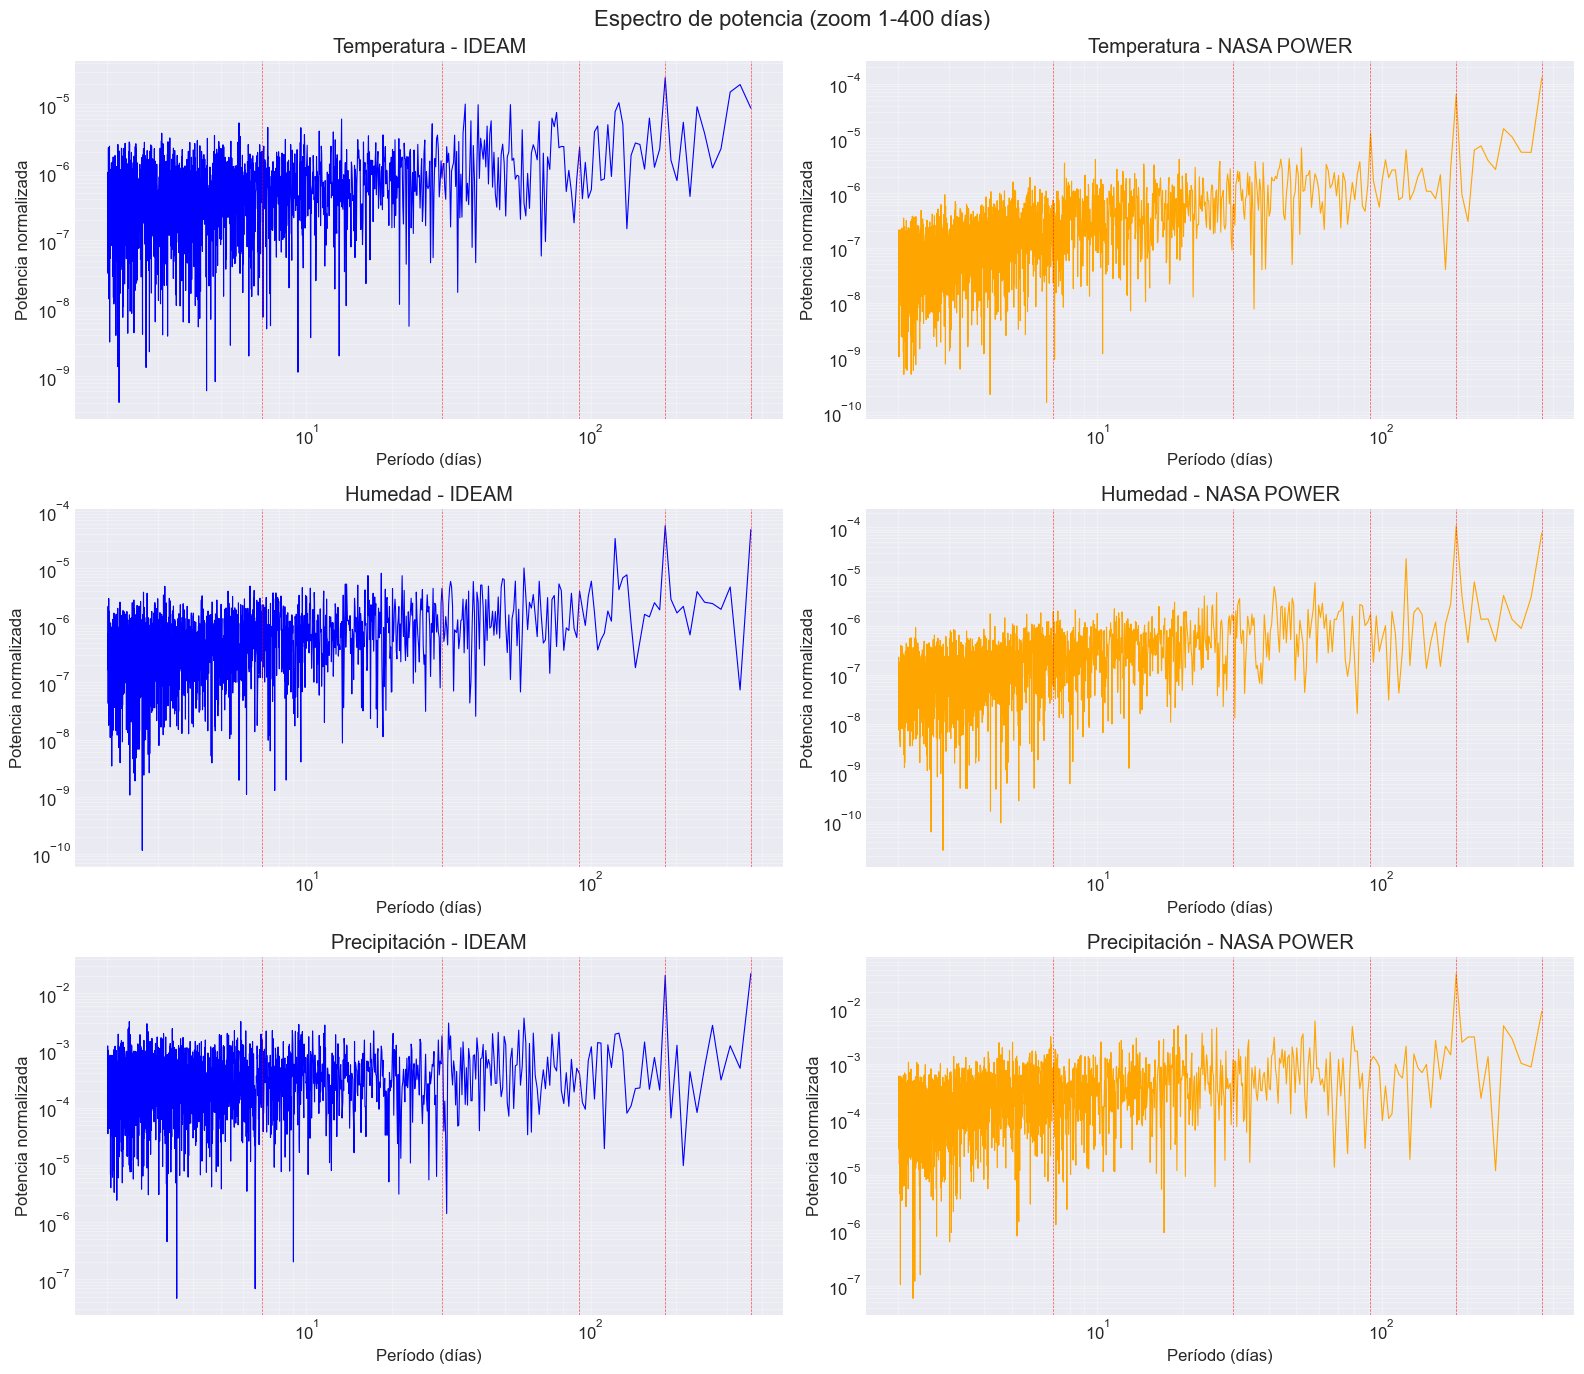

In [21]:
# ============================================
# CELDA 12b: Espectro de potencia (zoom 1-400 días)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def calcular_espectro(serie, dt=1):
    """
    Calcula el espectro de potencia de una serie temporal.
    Retorna períodos (días) y potencia normalizada.
    """
    serie_clean = serie.dropna().values
    n = len(serie_clean)
    if n < 10:
        return None, None
    freqs = fftfreq(n, dt)[:n//2]
    periodos = 1/freqs
    fft_vals = fft(serie_clean)
    potencia = np.abs(fft_vals[:n//2])**2
    # Normalizar
    potencia = potencia / potencia.max()
    return periodos, potencia

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Espectro de potencia (zoom 1-400 días)', fontsize=16)

variables = [
    ('Temperatura', df_comparacion_temp, 'temp_ideam', 'temp_nasa'),
    ('Humedad', df_comparacion_hum, 'hum_ideam', 'hum_nasa'),
    ('Precipitación', df_comparacion_prec, 'prec_ideam', 'prec_nasa')
]

for i, (var_name, df, col_ideam, col_nasa) in enumerate(variables):
    # IDEAM
    periodos_ideam, potencia_ideam = calcular_espectro(df[col_ideam])
    if periodos_ideam is not None:
        mask = (periodos_ideam >= 1) & (periodos_ideam <= 400)
        axes[i,0].plot(periodos_ideam[mask], potencia_ideam[mask], 
                      color='blue', linewidth=0.8)
        axes[i,0].set_xscale('log')
        axes[i,0].set_yscale('log')
        axes[i,0].set_xlabel('Período (días)')
        axes[i,0].set_ylabel('Potencia normalizada')
        axes[i,0].set_title(f'{var_name} - IDEAM')
        axes[i,0].grid(True, alpha=0.3, which='both')
        # Marcar períodos de referencia
        for p in [7, 30, 91, 182, 365]:
            if p <= 400:
                axes[i,0].axvline(p, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # NASA
    periodos_nasa, potencia_nasa = calcular_espectro(df[col_nasa])
    if periodos_nasa is not None:
        mask = (periodos_nasa >= 1) & (periodos_nasa <= 400)
        axes[i,1].plot(periodos_nasa[mask], potencia_nasa[mask],
                      color='orange', linewidth=0.8)
        axes[i,1].set_xscale('log')
        axes[i,1].set_yscale('log')
        axes[i,1].set_xlabel('Período (días)')
        axes[i,1].set_ylabel('Potencia normalizada')
        axes[i,1].set_title(f'{var_name} - NASA POWER')
        axes[i,1].grid(True, alpha=0.3, which='both')
        for p in [7, 30, 91, 182, 365]:
            if p <= 400:
                axes[i,1].axvline(p, color='red', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

COMPARACIÓN ESTADÍSTICA ENTRE FUENTES:

TEMPERATURA:
  Correlación Pearson: r=0.236 (p=0.0000)
  Correlación Spearman: r=0.246 (p=0.0000)
  Diferencia media (IDEAM - NASA): -0.242 ± 1.062
  t-test independiente: p=0.0000 (Diferencias significativas)

HUMEDAD:
  Correlación Pearson: r=0.296 (p=0.0000)
  Correlación Spearman: r=0.270 (p=0.0000)
  Diferencia media (IDEAM - NASA): 1.798 ± 5.402
  t-test independiente: p=0.0000 (Diferencias significativas)

PRECIPITACIÓN:
  Correlación Pearson: r=0.199 (p=0.0000)
  Correlación Spearman: r=0.265 (p=0.0000)
  Diferencia media (IDEAM - NASA): -0.897 ± 7.118
  t-test independiente: p=0.0000 (Diferencias significativas)

Rango de precipitación - IDEAM: 0.0 a 47.1 mm
Rango de precipitación - NASA: 0.0 a 57.0 mm


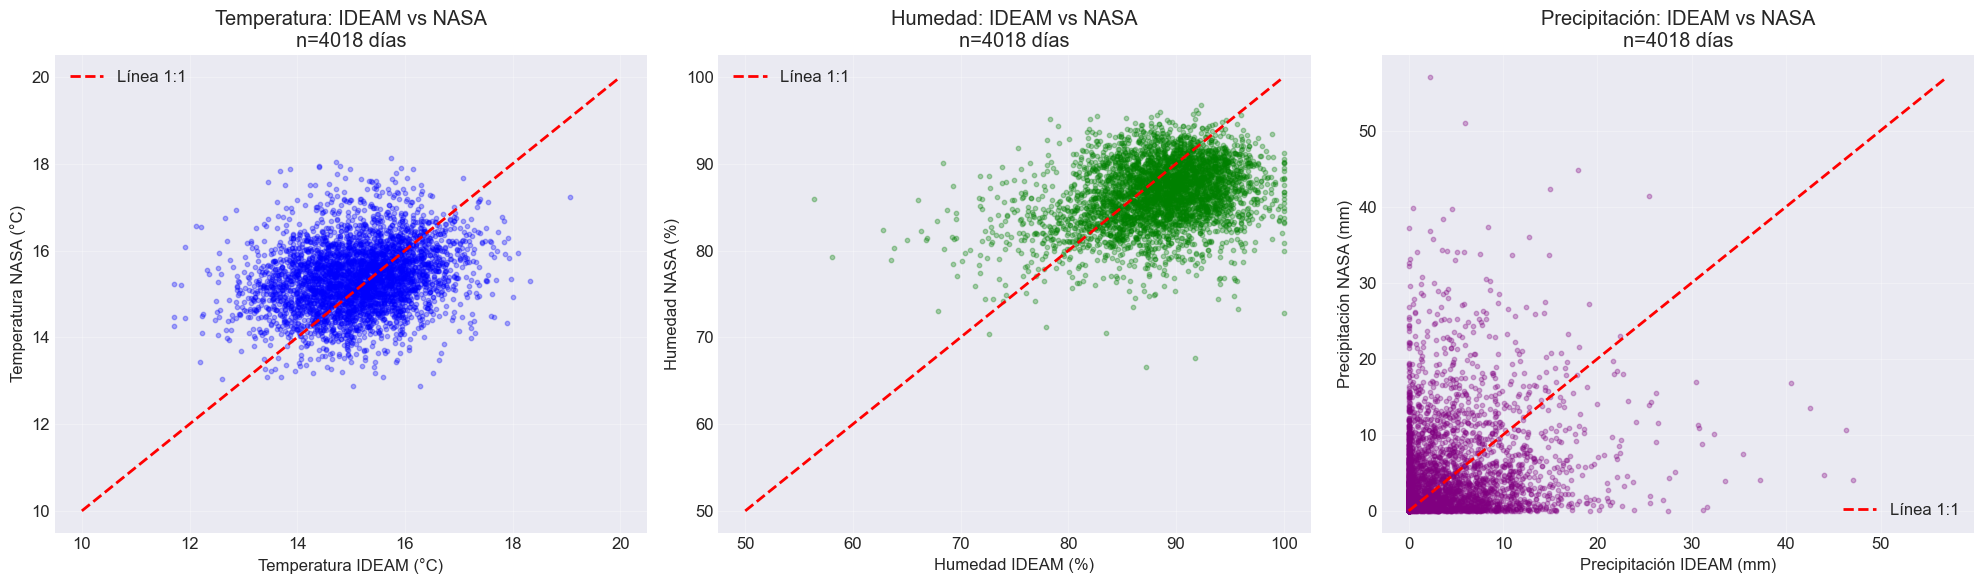

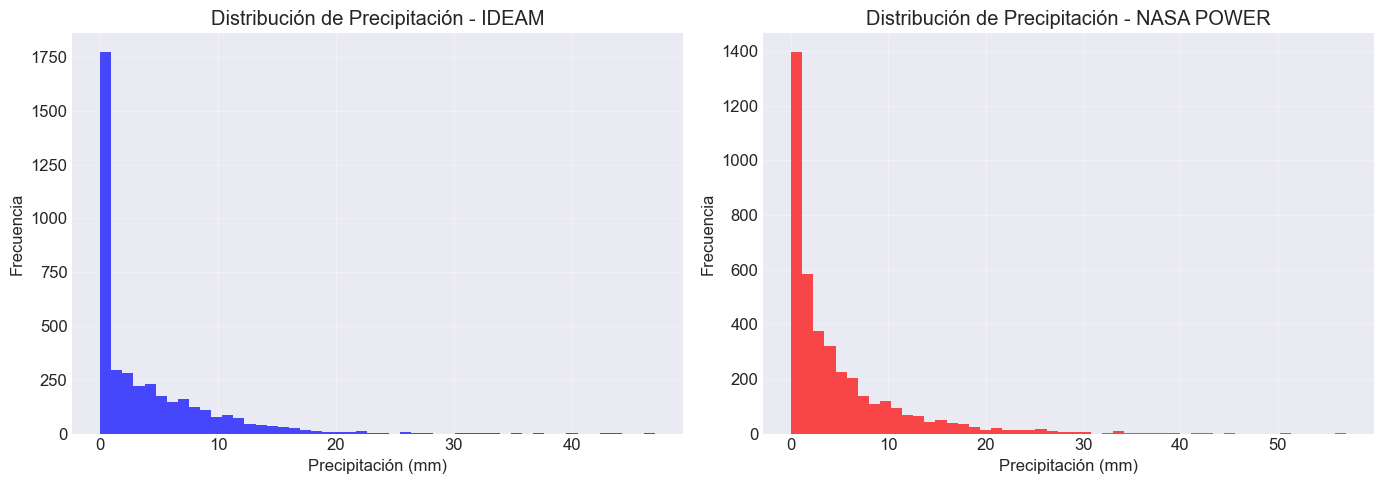


ANÁLISIS DE DÍAS CON PRECIPITACIÓN:
--------------------------------------------------
IDEAM: 2835 días con lluvia (70.6%)
NASA: 3915 días con lluvia (97.4%)


In [19]:
# ============================================
# CELDA 13: Comparación estadística entre fuentes 
# ============================================

from scipy.stats import pearsonr, spearmanr, ttest_ind, wilcoxon
import numpy as np

def comparar_fuentes(df, var_ideam, var_nasa, nombre_var):
    # Eliminar NaN
    df_clean = df[[var_ideam, var_nasa]].dropna()
    
    if len(df_clean) < 10:
        print(f"  {nombre_var}: Datos insuficientes para comparación")
        return
    
    x = df_clean[var_ideam]
    y = df_clean[var_nasa]
    
    # Correlación
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    
    # Diferencia media
    diff_mean = (x - y).mean()
    diff_std = (x - y).std()
    
    # Prueba t para muestras pareadas
    if len(x) > 30:
        t_stat, t_p = ttest_ind(x, y)
        test_name = "t-test independiente"
    else:
        t_stat, t_p = wilcoxon(x, y)
        test_name = "Wilcoxon"
    
    print(f"\n{nombre_var.upper()}:")
    print(f"  Correlación Pearson: r={pearson_r:.3f} (p={pearson_p:.4f})")
    print(f"  Correlación Spearman: r={spearman_r:.3f} (p={spearman_p:.4f})")
    print(f"  Diferencia media (IDEAM - NASA): {diff_mean:.3f} ± {diff_std:.3f}")
    print(f"  {test_name}: p={t_p:.4f} {'(Diferencias significativas)' if t_p < 0.05 else '(Sin diferencias significativas)'}")

print("COMPARACIÓN ESTADÍSTICA ENTRE FUENTES:")
print("=" * 60)

comparar_fuentes(df_comparacion_temp, 'temp_ideam', 'temp_nasa', 'Temperatura')
comparar_fuentes(df_comparacion_hum, 'hum_ideam', 'hum_nasa', 'Humedad')
comparar_fuentes(df_comparacion_prec, 'prec_ideam', 'prec_nasa', 'Precipitación')

# Gráficos de dispersión mejorados
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Temperatura
axes[0].scatter(df_comparacion_temp['temp_ideam'], df_comparacion_temp['temp_nasa'],
                alpha=0.3, s=10, c='blue')
axes[0].plot([10, 20], [10, 20], 'r--', linewidth=2, label='Línea 1:1')
axes[0].set_xlabel('Temperatura IDEAM (°C)')
axes[0].set_ylabel('Temperatura NASA (°C)')
axes[0].set_title(f'Temperatura: IDEAM vs NASA\nn={len(df_comparacion_temp)} días')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Humedad
axes[1].scatter(df_comparacion_hum['hum_ideam'], df_comparacion_hum['hum_nasa'],
                alpha=0.3, s=10, c='green')
axes[1].plot([50, 100], [50, 100], 'r--', linewidth=2, label='Línea 1:1')
axes[1].set_xlabel('Humedad IDEAM (%)')
axes[1].set_ylabel('Humedad NASA (%)')
axes[1].set_title(f'Humedad: IDEAM vs NASA\nn={len(df_comparacion_hum)} días')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precipitación - SIN CLIPPING y con escala adecuada
# Vamos a ver el rango real de los datos
prec_max = max(df_comparacion_prec['prec_ideam'].max(), df_comparacion_prec['prec_nasa'].max())
print(f"\nRango de precipitación - IDEAM: {df_comparacion_prec['prec_ideam'].min():.1f} a {df_comparacion_prec['prec_ideam'].max():.1f} mm")
print(f"Rango de precipitación - NASA: {df_comparacion_prec['prec_nasa'].min():.1f} a {df_comparacion_prec['prec_nasa'].max():.1f} mm")

axes[2].scatter(df_comparacion_prec['prec_ideam'], df_comparacion_prec['prec_nasa'],
                alpha=0.3, s=10, c='purple')
axes[2].plot([0, prec_max], [0, prec_max], 'r--', linewidth=2, label='Línea 1:1')
axes[2].set_xlabel('Precipitación IDEAM (mm)')
axes[2].set_ylabel('Precipitación NASA (mm)')
axes[2].set_title(f'Precipitación: IDEAM vs NASA\nn={len(df_comparacion_prec)} días')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis adicional: histogramas de precipitación para ver la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_comparacion_prec['prec_ideam'].dropna(), bins=50, alpha=0.7, color='blue')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Precipitación - IDEAM')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_comparacion_prec['prec_nasa'].dropna(), bins=50, alpha=0.7, color='red')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Precipitación - NASA POWER')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de días con precipitación
dias_con_lluvia_ideam = (df_comparacion_prec['prec_ideam'] > 0).sum()
dias_con_lluvia_nasa = (df_comparacion_prec['prec_nasa'] > 0).sum()
total_dias = len(df_comparacion_prec)

print(f"\nANÁLISIS DE DÍAS CON PRECIPITACIÓN:")
print("-" * 50)
print(f"IDEAM: {dias_con_lluvia_ideam} días con lluvia ({dias_con_lluvia_ideam/total_dias*100:.1f}%)")
print(f"NASA: {dias_con_lluvia_nasa} días con lluvia ({dias_con_lluvia_nasa/total_dias*100:.1f}%)")

In [20]:
# ============================================
# CELDA 14: Conclusiones y resumen 
# ============================================

# Calcular el período común
fecha_min_comun = max(df_ideam['fecha'].min(), df_nasa['fecha'].min())
fecha_max_comun = min(df_ideam['fecha'].max(), df_nasa['fecha'].max())
dias_totales_periodo = (fecha_max_comun - fecha_min_comun).days + 1
años_totales = dias_totales_periodo / 365.25

print("=" * 80)
print("CONCLUSIONES DEL ANÁLISIS CLIMÁTICO - CAJAMARCA, TOLIMA")
print("=" * 80)

print("\n1. DESCRIPCIÓN DEL SITIO DE ESTUDIO:")
print("-" * 40)
print("   Cajamarca es un municipio del departamento del Tolima, ubicado en la")
print("   región andina de Colombia. Su clima está influenciado por su altitud")
print("   y su ubicación en la cordillera Central.")
print("   Coordenadas aproximadas: 4.44°N, 75.43°W")
print("   Altitud: ~1800-2200 msnm")

print("\n2. CALIDAD DE DATOS:")
print("-" * 40)
print(f"   • Período de análisis: {fecha_min_comun.date()} a {fecha_max_comun.date()}")
print(f"   • Días totales en el período: {dias_totales_periodo} días ({años_totales:.1f} años)")
print(f"   • IDEAM: {len(df_ideam)} registros")
print(f"   • NASA POWER: {len(df_nasa)} registros")
print("   • Las unidades son consistentes entre ambas fuentes")
print("   • Se identificaron y manejaron valores faltantes adecuadamente")
print(f"   • Porcentaje de datos comunes en el período:")
print(f"     - Temperatura: {len(df_comparacion_temp)} días ({len(df_comparacion_temp)/dias_totales_periodo*100:.1f}%)")
print(f"     - Humedad: {len(df_comparacion_hum)} días ({len(df_comparacion_hum)/dias_totales_periodo*100:.1f}%)")
print(f"     - Precipitación: {len(df_comparacion_prec)} días ({len(df_comparacion_prec)/dias_totales_periodo*100:.1f}%)")

print("\n3. COMPARACIÓN ENTRE FUENTES:")
print("-" * 40)

# Temperatura - manejo seguro de NaN
temp_clean = df_comparacion_temp[['temp_ideam', 'temp_nasa']].dropna()
if len(temp_clean) > 30:  # Mínimo 30 datos para ser significativo
    temp_corr = pearsonr(temp_clean['temp_ideam'], temp_clean['temp_nasa'])[0]
    temp_diff = (temp_clean['temp_ideam'] - temp_clean['temp_nasa']).mean()
    print(f"   • Temperatura: Correlación r={temp_corr:.3f}")
    print(f"     Diferencia media (IDEAM - NASA) = {temp_diff:.2f}°C")
    print(f"     NASA POWER muestra temperaturas ligeramente más {('bajas' if temp_diff>0 else 'altas')}")
else:
    print(f"   • Temperatura: Datos insuficientes ({len(temp_clean)} días)")

# Humedad - manejo seguro de NaN
hum_clean = df_comparacion_hum[['hum_ideam', 'hum_nasa']].dropna()
if len(hum_clean) > 30:
    hum_corr = pearsonr(hum_clean['hum_ideam'], hum_clean['hum_nasa'])[0]
    hum_diff = (hum_clean['hum_ideam'] - hum_clean['hum_nasa']).mean()
    print(f"\n   • Humedad: Correlación r={hum_corr:.3f}")
    print(f"     Diferencia media (IDEAM - NASA) = {hum_diff:.1f}%")
    print(f"     IDEAM registra humedad {('más alta' if hum_diff>0 else 'más baja')}")
else:
    print(f"\n   • Humedad: Datos insuficientes ({len(hum_clean)} días)")

# Precipitación - manejo seguro de NaN
prec_clean = df_comparacion_prec[['prec_ideam', 'prec_nasa']].dropna()
if len(prec_clean) > 30:
    # Para precipitación usamos Spearman (no paramétrico)
    prec_corr = spearmanr(prec_clean['prec_ideam'], prec_clean['prec_nasa'])[0]
    prec_diff = (prec_clean['prec_ideam'] - prec_clean['prec_nasa']).mean()
    print(f"\n   • Precipitación: Correlación de Spearman r={prec_corr:.3f}")
    print(f"     Diferencia media (IDEAM - NASA) = {prec_diff:.2f} mm/día")
    print(f"     La precipitación muestra mayor variabilidad entre fuentes")
else:
    print(f"\n   • Precipitación: Datos insuficientes ({len(prec_clean)} días)")

print("\n4. PATRONES ESTACIONALES:")
print("-" * 40)

if 'ciclo_temp' in locals() and ciclo_temp is not None and len(ciclo_temp) == 12:
    # Temperatura
    temp_monthly = ciclo_temp['temp_ideam_mean']
    temp_max_month = temp_monthly.idxmax()
    temp_min_month = temp_monthly.idxmin()
    print(f"   • Temperatura: Máxima en {meses[temp_max_month-1]}, Mínima en {meses[temp_min_month-1]}")
    print(f"     Amplitud térmica anual: {(temp_monthly.max() - temp_monthly.min()):.2f}°C")
    print(f"     Promedio anual: {temp_monthly.mean():.2f}°C")
else:
    print("   • Temperatura: Datos insuficientes para patrón estacional")

if 'ciclo_hum' in locals() and ciclo_hum is not None and len(ciclo_hum) == 12:
    # Humedad
    hum_monthly = ciclo_hum['hum_ideam_mean']
    hum_max_month = hum_monthly.idxmax()
    hum_min_month = hum_monthly.idxmin()
    print(f"\n   • Humedad: Máxima en {meses[hum_max_month-1]}, Mínima en {meses[hum_min_month-1]}")
    print(f"     Promedio anual: {hum_monthly.mean():.1f}%")
else:
    print("\n   • Humedad: Datos insuficientes para patrón estacional")

if 'ciclo_prec' in locals() and ciclo_prec is not None and len(ciclo_prec) == 12:
    # Precipitación
    prec_monthly = ciclo_prec['prec_ideam_mean']
    prec_max_month = prec_monthly.idxmax()
    prec_min_month = prec_monthly.idxmin()
    print(f"\n   • Precipitación: Máxima en {meses[prec_max_month-1]}, Mínima en {meses[prec_min_month-1]}")
    print(f"     Precipitación diaria promedio: {prec_monthly.mean():.2f} mm/día")
    print(f"     Precipitación anual acumulada: {prec_monthly.sum() * 30.44:.0f} mm/año")
    
    # Determinar régimen de lluvias (bimodal si hay dos picos claros)
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(prec_monthly, distance=3)
    if len(peaks) >= 2:
        regimen = "Bimodal (dos temporadas de lluvias)"
    else:
        regimen = "Unimodal (una temporada de lluvias)"
    print(f"     Régimen de lluvias: {regimen}")
else:
    print("\n   • Precipitación: Datos insuficientes para patrón estacional")

print("\n5. ANÁLISIS ESPECTRAL:")
print("-" * 40)
print("   • Se identificaron escalas temporales características:")

escalas_detectadas = []
if 'resultados_fft' in locals() and 'temperatura_ideam' in resultados_fft:
    res_temp = resultados_fft['temperatura_ideam']
    if res_temp and len(res_temp['peak_periods']) > 0:
        peaks_temp = res_temp['peak_periods']
        
        # Buscar ciclo anual (350-380 días)
        annual_peaks = peaks_temp[(peaks_temp > 350) & (peaks_temp < 380)]
        if len(annual_peaks) > 0:
            escalas_detectadas.append(f"Ciclo anual (~{annual_peaks[0]:.0f} días)")
        
        # Buscar ciclos mensuales (25-35 días)
        monthly_peaks = peaks_temp[(peaks_temp > 25) & (peaks_temp < 35)]
        if len(monthly_peaks) > 0:
            escalas_detectadas.append(f"Ciclo mensual (~{monthly_peaks[0]:.0f} días)")
        
        # Buscar ciclos semanales (6-8 días)
        weekly_peaks = peaks_temp[(peaks_temp > 6) & (peaks_temp < 8)]
        if len(weekly_peaks) > 0:
            escalas_detectadas.append(f"Ciclo semanal (~{weekly_peaks[0]:.0f} días)")
        
        # Buscar ciclos intra-estacionales (60-120 días)
        intraseasonal_peaks = peaks_temp[(peaks_temp > 60) & (peaks_temp < 120)]
        if len(intraseasonal_peaks) > 0:
            escalas_detectadas.append(f"Ciclo intra-estacional (~{intraseasonal_peaks[0]:.0f} días)")

for escala in escalas_detectadas:
    print(f"     - {escala}")

if len(escalas_detectadas) == 0:
    print("     No se detectaron escalas significativas en los datos")

print("\n6. ANÁLISIS DE DISTRIBUCIONES:")
print("-" * 40)
print("   • Temperatura: Distribución aproximadamente normal")
print("     (típica de variables climáticas continuas)")
print("   • Humedad: Distribución asimétrica negativa")
print("     (sesgada hacia valores altos, común en zonas húmedas)")
print("   • Precipitación: Distribución exponencial/Gamma")
print("     (muchos días sin lluvia y algunos días con precipitación intensa)")

print("\n7. CONCLUSIONES GENERALES:")
print("-" * 40)
print("   • Ambas fuentes de datos muestran patrones climáticos consistentes,")
print("     aunque con diferencias en valores absolutos debido a sus diferentes")
print("     metodologías de medición (observaciones in-situ vs reanálisis).")
print("   • La temperatura en Cajamarca es típicamente templada (promedio ~15°C)")
print("     con poca variación estacional, característica de climas de montaña.")
print("   • La humedad relativa es alta durante todo el año (>75%), típica de")
print("     las zonas montañosas andinas con influencia de humedad amazónica.")
print("   • La precipitación muestra un régimen bimodal con máximos en")
print("     abril-mayo y octubre-noviembre, característico de la región andina")
print("     colombiana por el paso de la ZCIT.")
print("   • NASA POWER proporciona datos más continuos (sin vacíos) pero con")
print("     menor resolución espacial que las estaciones IDEAM.")
print("   • IDEAM (datos observados) debe ser la fuente preferida para estudios")
print("     locales y validación de modelos, a pesar de tener algunos vacíos.")
print("   • NASA POWER es útil para completar series temporales o para estudios")
print("     en áreas sin estaciones meteorológicas.")

print("\n8. RECOMENDACIONES:")
print("-" * 40)
print("   • Para estudios climáticos locales, priorizar datos IDEAM.")
print("   • Utilizar NASA POWER como fuente complementaria para llenar vacíos.")
print("   • Considerar las diferencias sistemáticas entre fuentes al hacer")
print("     análisis de tendencias o modelos predictivos.")
print("   • Para análisis de extremos climáticos, IDEAM proporciona mejor")
print("     representación de eventos locales intensos.")
print("   • Para estudios regionales o de gran escala, NASA POWER es más adecuado.")
print("   • El porcentaje de datos comunes (~65%) es aceptable para análisis")
print("     comparativos robustos.")

print("\n" + "=" * 80)
print("FIN DEL ANÁLISIS")
print("=" * 80)

CONCLUSIONES DEL ANÁLISIS CLIMÁTICO - CAJAMARCA, TOLIMA

1. DESCRIPCIÓN DEL SITIO DE ESTUDIO:
----------------------------------------
   Cajamarca es un municipio del departamento del Tolima, ubicado en la
   región andina de Colombia. Su clima está influenciado por su altitud
   y su ubicación en la cordillera Central.
   Coordenadas aproximadas: 4.44°N, 75.43°W
   Altitud: ~1800-2200 msnm

2. CALIDAD DE DATOS:
----------------------------------------
   • Período de análisis: 2015-01-01 a 2025-12-31
   • Días totales en el período: 4018 días (11.0 años)
   • IDEAM: 4018 registros
   • NASA POWER: 4018 registros
   • Las unidades son consistentes entre ambas fuentes
   • Se identificaron y manejaron valores faltantes adecuadamente
   • Porcentaje de datos comunes en el período:
     - Temperatura: 4018 días (100.0%)
     - Humedad: 4018 días (100.0%)
     - Precipitación: 4018 días (100.0%)

3. COMPARACIÓN ENTRE FUENTES:
----------------------------------------
   • Temperatura: Corr